In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import sys
import xgboost as xgb
import shap


ModuleNotFoundError: No module named 'xgboost'

In [27]:

print(sys.executable)

print("SHAP version :", shap.__version__)

print(xgb.__version__)


C:\Users\antoi\anaconda3\python.exe


NameError: name 'shap' is not defined

In [28]:

import subprocess
import importlib

print("=== ENVIRONNEMENT PYTHON ===")
print("Python executable :", sys.executable)

print("\n=== VERSION PIP ===")
subprocess.run([sys.executable, "-m", "pip", "--version"])

print("\n=== XGBOOST ===")
import xgboost
print("XGBoost version :", xgboost.__version__)

print("\n=== SHAP ===")
import shap
print("SHAP version :", shap.__version__)


=== ENVIRONNEMENT PYTHON ===
Python executable : C:\Users\antoi\anaconda3\python.exe

=== VERSION PIP ===

=== XGBOOST ===


ModuleNotFoundError: No module named 'xgboost'

In [29]:
# Configurer l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

   <h2 style="color: red;">   ÉTAPE 1  :  ANALYSE EXPLORATOIRE  </h2>

In [30]:
print("=" * 60)
print(" CHARGEMENT DES 3 FICHIERS")
print("=" * 60)

 CHARGEMENT DES 3 FICHIERS


In [31]:
extrait_eval = pd.read_csv("extrait_eval.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'extrait_eval.csv'

In [32]:
extrait_sirh = pd.read_csv("extrait_sirh.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'extrait_sirh.csv'

In [33]:
extrait_sondage=pd.read_csv("extrait_sondage.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'extrait_sondage.csv'

In [34]:
print(f" extrait_eval : {extrait_eval.shape[0]} lignes × {extrait_eval.shape[1]} colonnes")
print(f" extrait_sirh : {extrait_sirh.shape[0]} lignes × {extrait_sirh.shape[1]} colonnes")
print(f" extrait_sondage : {extrait_sondage.shape[0]} lignes × {extrait_sondage.shape[1]} colonnes")

NameError: name 'extrait_eval' is not defined

In [35]:
datasets = {
    "extrait_eval": extrait_eval,
    "extrait_sirh": extrait_sirh,
    "extrait_sondage": extrait_sondage
}

for nom, df in datasets.items():
    print("=" * 60)
    print(f" APERÇU DES DONNÉES – {nom}")
    print("=" * 60)
    display(df.head())


NameError: name 'extrait_eval' is not defined

In [36]:
extrait_eval = extrait_eval.copy()

rows = []

for c in extrait_eval.columns:
    s = extrait_eval[c]

    # valeurs uniques nettoyées 
    uniques = [
        v.item() if hasattr(v, "item") else v
        for v in s.dropna().unique()
    ]

    rows.append({
        "Columns": c,
        "Types": s.dtype,
        "Values": uniques if len(uniques) <= 10 else uniques[:10],  # limite à 10
        "Uniques": s.nunique(dropna=False),
        "Uniques(no nulls)": s.nunique(dropna=True),
        "Missing(n)": s.isna().sum(),
        "Missing(%)": round(s.isna().mean() * 100, 3)
    })

EDA = pd.DataFrame(rows)

EDA_style = EDA.style.set_table_styles([
    {'selector': 'thead', 'props': [('background-color', '#2E86C1'),
                                    ('color', 'white'),
                                    ('font-weight', 'bold')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#D6EAF8')]}
]).set_properties(**{
    'border': '1px solid gray',
    'text-align': 'center'
})

EDA_style


NameError: name 'extrait_eval' is not defined

In [37]:
extrait_sirh = extrait_sirh.copy()

rows = []

for c in extrait_sirh.columns:
    s = extrait_sirh[c]

    # valeurs uniques nettoyées 
    uniques = [
        v.item() if hasattr(v, "item") else v
        for v in s.dropna().unique()
    ]

    rows.append({
        "Columns": c,
        "Types": s.dtype,
        "Values": uniques if len(uniques) <= 10 else uniques[:10],  # limite à 10
        "Uniques": s.nunique(dropna=False),
        "Uniques(no nulls)": s.nunique(dropna=True),
        "Missing(n)": s.isna().sum(),
        "Missing(%)": round(s.isna().mean() * 100, 3)
    })

EDA = pd.DataFrame(rows)

EDA_style = EDA.style.set_table_styles([
    {'selector': 'thead', 'props': [('background-color', '#2E86C1'),
                                    ('color', 'white'),
                                    ('font-weight', 'bold')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#D6EAF8')]}
]).set_properties(**{
    'border': '1px solid gray',
    'text-align': 'center'
})

EDA_style


NameError: name 'extrait_sirh' is not defined

In [12]:
extrait_sondage = extrait_sondage.copy()

rows = []

for c in extrait_sondage.columns:
    s = extrait_sondage[c]

    # valeurs uniques nettoyées (numpy 
    uniques = [
        v.item() if hasattr(v, "item") else v
        for v in s.dropna().unique()
    ]

    rows.append({
        "Columns": c,
        "Types": s.dtype,
        "Values": uniques if len(uniques) <= 10 else uniques[:10],  # limite à 10
        "Uniques": s.nunique(dropna=False),
        "Uniques(no nulls)": s.nunique(dropna=True),
        "Missing(n)": s.isna().sum(),
        "Missing(%)": round(s.isna().mean() * 100, 3)
    })

EDA = pd.DataFrame(rows)

EDA_style = EDA.style.set_table_styles([
    {'selector': 'thead', 'props': [('background-color', '#2E86C1'),
                                    ('color', 'white'),
                                    ('font-weight', 'bold')]},
    {'selector': 'tbody tr:hover',
     'props': [('background-color', '#D6EAF8')]}
]).set_properties(**{
    'border': '1px solid gray',
    'text-align': 'center'
})

EDA_style


NameError: name 'extrait_sondage' is not defined

In [13]:
#  graphe pour repartire les typres de variables
extrait_eval.dtypes.value_counts().plot( kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue','orange' , 'seagreen',  'blue'] , wedgeprops={'edgecolor': 'red'} )
plt.title (" les types de variables")
plt.tight_layout()
plt.show()

NameError: name 'extrait_eval' is not defined

In [14]:

def detect_type(col):
    if col.dtype == 'bool':
        return 'Bool'
    elif col.dropna().isin([0,1]).all():
        return 'Bool (0/1)'
    elif col.dtype == 'object':
        return 'Catégorielle'
    elif col.dtype in ['int64','float64']:
        return 'Numérique'
    else:
        return 'Autre'

type_series = extrait_sirh.apply(detect_type)

type_series.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Répartition réelle des types de variables")
plt.show()


NameError: name 'extrait_sirh' is not defined

In [15]:
#  graphe pour repartire les typres de variables
extrait_sondage.dtypes.value_counts().plot( kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue','orange' , 'seagreen',  'blue'] , wedgeprops={'edgecolor': 'red'} )
plt.title (" les types de variables")
plt.tight_layout()
plt.show()

NameError: name 'extrait_sondage' is not defined

In [16]:
# -------------------------------------------------
# 2. FONCTION POUR ANALYSER UN DATASET
# -------------------------------------------------
def analyser_dataset(df, nom="Dataset"):
    """
    Fonction qui analyse un dataset et retourne un résumé
    """
    print(f"\n" + "=" * 60)
    print(f" ANALYSE : {nom}")
    print("=" * 60)
    
    # A. Informations de base
    print(f"\n INFORMATIONS DE BASE :")
    print(f"   Shape: {df.shape}")
    print(f"   Colonnes: {len(df.columns)}")
    
    # B. Types de données
    print(f"\n TYPES DE DONNÉES :")
    print(df.dtypes.value_counts())
    
    # C. Valeurs manquantes
    print(f"\n  VALEURS MANQUANTES :")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    if missing.sum() > 0:
        missing_df = pd.DataFrame({
            'Valeurs manquantes': missing[missing > 0],
            'Pourcentage': missing_percent[missing > 0]
        })
        print(missing_df.sort_values('Pourcentage', ascending=False).head(10))
    else:
        print("    Aucune valeur manquante")
        
    
    # D. Statistiques descriptives
    print(f"\n STATISTIQUES DESCRIPTIVES (5 premières colonnes numériques) :")
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        print(df[num_cols[:5]].describe())
    
    # E. Colonnes catégorielles
    print(f"\n COLONNES CATÉGORIELLES :")
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        for col in cat_cols[:5]:  # Limiter aux 5 premières
            print(f"\n   {col}:")
            print(f"   Valeurs uniques: {df[col].nunique()}")
            if df[col].nunique() <= 10:
                print(f"   Distribution:")
                print(df[col].value_counts())
    
    # F. Doublons
    print(f"\n DOUBLONS :")
    duplicates = df.duplicated().sum()
    print(f"   {duplicates} doublons complets")
    
    return df

    

In [17]:

# -------------------------------------------------
# 3. ANALYSER CHAQUE DATASET
# -------------------------------------------------

# Analyse de chaque dataset
df_eval = analyser_dataset(extrait_eval, "EXTRACTION ÉVALUATIONS")
df_sirh = analyser_dataset(extrait_sirh, "EXTRACTION SIRH")
df_sondage = analyser_dataset(extrait_sondage, "EXTRACTION SONDAGE")

# -------------------------------------------------
# 4. ANALYSE COMPARATIVE
# -------------------------------------------------
print("\n" + "=" * 60)
print(" ANALYSE COMPARATIVE DES 3 DATASETS")
print("=" * 60)

# Créer un tableau comparatif
comparaison = pd.DataFrame({
    'Dataset': ['extrait_eval', 'extrait_sirh', 'extrait_sondage'],
    'Lignes': [len(df_eval), len(df_sirh), len(df_sondage)],
    'Colonnes': [len(df_eval.columns), len(df_sirh.columns), len(df_sondage.columns)],
    'Valeurs manquantes': [df_eval.isnull().sum().sum(), 
                          df_sirh.isnull().sum().sum(), 
                          df_sondage.isnull().sum().sum()],
    'Doublons': [df_eval.duplicated().sum(), 
                df_sirh.duplicated().sum(), 
                df_sondage.duplicated().sum()]
})

print("\n TABLEAU COMPARATIF :")
print(comparaison)


NameError: name 'extrait_eval' is not defined

In [18]:
# -------------------------------------------------
# 4. ANALYSE COMPARATIVE
# -------------------------------------------------
print("\n" + "=" * 60)
print(" ANALYSE COMPARATIVE DES 3 DATASETS")
print("=" * 60)

# Créer un tableau comparatif
comparaison = pd.DataFrame({
    'Dataset': ['extrait_eval', 'extrait_sirh', 'extrait_sondage'],
    'Lignes': [len(df_eval), len(df_sirh), len(df_sondage)],
    'Colonnes': [len(df_eval.columns), len(df_sirh.columns), len(df_sondage.columns)],
    'Valeurs manquantes': [df_eval.isnull().sum().sum(), 
                          df_sirh.isnull().sum().sum(), 
                          df_sondage.isnull().sum().sum()],
    'Doublons': [df_eval.duplicated().sum(), 
                df_sirh.duplicated().sum(), 
                df_sondage.duplicated().sum()]
})

print("\n TABLEAU COMPARATIF :")
print(comparaison)



 ANALYSE COMPARATIVE DES 3 DATASETS


NameError: name 'df_eval' is not defined


 VISUALISATIONS


NameError: name 'comparaison' is not defined

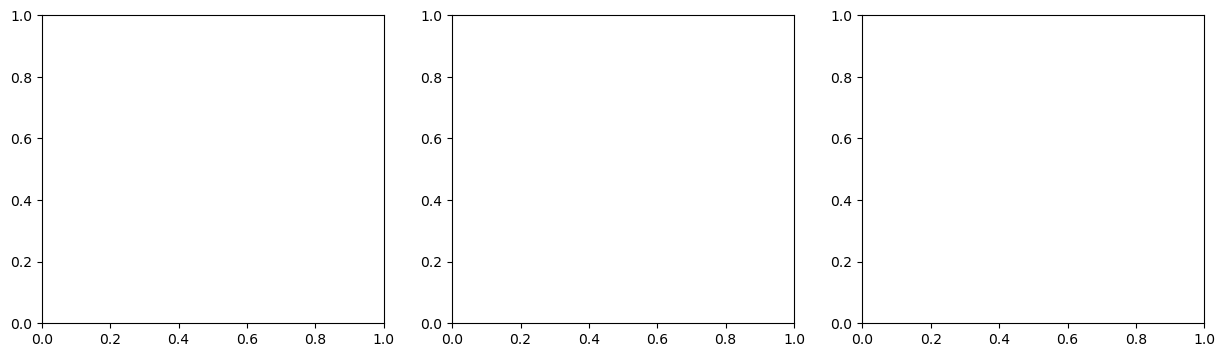

In [19]:
# -------------------------------------------------
# 5. VISUALISATIONS DE BASE
# -------------------------------------------------
print("\n" + "=" * 60)
print(" VISUALISATIONS")
print("=" * 60)

# A. Taille des datasets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Nombre de lignes
axes[0].bar(comparaison['Dataset'], comparaison['Lignes'], color='skyblue')
axes[0].set_title('Nombre de lignes par dataset')
axes[0].set_ylabel('Nombre de lignes')
axes[0].tick_params(axis='x', rotation=45)

# 2. Nombre de colonnes
axes[1].bar(comparaison['Dataset'], comparaison['Colonnes'], color='lightgreen')
axes[1].set_title('Nombre de colonnes par dataset')
axes[1].set_ylabel('Nombre de colonnes')
axes[1].tick_params(axis='x', rotation=45)

# 3. Valeurs manquantes
axes[2].bar(comparaison['Dataset'], comparaison['Valeurs manquantes'], color='salmon')
axes[2].set_title('Valeurs manquantes totales par dataset')
axes[2].set_ylabel('Valeurs manquantes')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
# -------------------------------------------------
# 6. AFFICHER LES COLONNES DE CHAQUE DATASET
# -------------------------------------------------
print("\n" + "=" * 60)
print(" LISTE DES COLONNES PAR DATASET")
print("=" * 60)

print("\n extrait_eval COLUMNS :")
for i, col in enumerate(df_eval.columns, 1):
    print(f"{i:3d}. {col}")
print("\n" + "=" * 60)
print("\n\n extrait_sirh COLUMNS :")
for i, col in enumerate(df_sirh.columns, 1):
    print(f"{i:3d}. {col}")
print("\n" + "=" * 60)
print("\n\n extrait_sondage COLUMNS :")
for i, col in enumerate(df_sondage.columns, 1):
    print(f"{i:3d}. {col}")


 LISTE DES COLONNES PAR DATASET

 extrait_eval COLUMNS :


NameError: name 'df_eval' is not defined

In [21]:
print("\n" + "=" * 60)
print(" RENOMER UNE COLONNE SUPLEMENTAIRE EN ENLEVNT LE E_ ")
print("=" * 60)

extrait_eval['id_employee'] = (
    extrait_eval['eval_number']
    .str.replace('E_', '', regex=False)
    .astype(int)
)
extrait_eval[['eval_number', 'id_employee']].head(-50)


 RENOMER UNE COLONNE SUPLEMENTAIRE EN ENLEVNT LE E_ 


NameError: name 'extrait_eval' is not defined

In [22]:
# ============================================
# VÉRIFICATION ET JOINTURE DES 3 DATASETS
# ============================================

print("=" * 60)
print(" VÉRIFICATION DES COLONNES DE JOINTURE")
print("=" * 60)

# 1. Vérifier que les valeurs correspondent vraiment
print("\n COMPARAISON DES VALEURS :")

# Prendre un échantillon aléatoire de 10 IDs
import random
sample_ids = random.sample(list(extrait_eval['id_employee'].dropna().unique()), 10)

print("\n Échantillon de 10 IDs pour vérification :")
for emp_id in sample_ids:
    in_eval = emp_id in extrait_eval['id_employee'].values
    in_sirh = emp_id in extrait_sirh['id_employee'].values
    in_sondage = emp_id in extrait_sondage['code_sondage'].values
    
    print(f"ID {emp_id:4d} : ", end="")
    if in_eval:
        print(" Eval ", end="")
    else:
        print(" Eval ", end="")
    
    if in_sirh:
        print("  SIRH ", end="")
    else:
        print(" SIRH ", end="")
    
    if in_sondage:
        print(" Sondage")
    else:
        print(" Sondage")

 VÉRIFICATION DES COLONNES DE JOINTURE

 COMPARAISON DES VALEURS :


NameError: name 'extrait_eval' is not defined

In [23]:

# 2. Statistiques complètes
print("\n STATISTIQUES DE JOINTURE :")
print(f"Evaluations : {extrait_eval['id_employee'].nunique()} IDs uniques")
print(f"SIRH        : {extrait_sirh['id_employee'].nunique()} IDs uniques")
print(f"Sondage     : {extrait_sondage['code_sondage'].nunique()} IDs uniques")

# 3. Vérifier les correspondances exactes
ids_eval = set(extrait_eval['id_employee'].dropna().unique())
ids_sirh = set(extrait_sirh['id_employee'].dropna().unique())
ids_sondage = set(extrait_sondage['code_sondage'].dropna().unique())

print("\n INTERSECTIONS :")
print(f"Eval ∩ SIRH      : {len(ids_eval & ids_sirh)} IDs communs")
print(f"Eval ∩ Sondage   : {len(ids_eval & ids_sondage)} IDs communs")
print(f"SIRH ∩ Sondage   : {len(ids_sirh & ids_sondage)} IDs communs")
print(f"Tous ∩ Tous      : {len(ids_eval & ids_sirh & ids_sondage)} IDs communs aux 3")

# 4. IDs manquants
print("\n  IDs MANQUANTS :")
print(f"Dans Eval mais pas SIRH      : {len(ids_eval - ids_sirh)}")
print(f"Dans Eval mais pas Sondage   : {len(ids_eval - ids_sondage)}")
print(f"Dans SIRH mais pas Eval      : {len(ids_sirh - ids_eval)}")
print(f"Dans Sondage mais pas Eval   : {len(ids_sondage - ids_eval)}")


 STATISTIQUES DE JOINTURE :


NameError: name 'extrait_eval' is not defined

In [30]:
# ============================================
# JOINTURE DES 3 DATASETS
# ============================================

print("\n" + "=" * 60)
print(" JOINTURE DES 3 DATASETS")
print("=" * 60)

# A. Renommer la colonne dans sondage pour avoir le même nom
extrait_sondage_renamed = extrait_sondage.rename(columns={'code_sondage': 'id_employee'})

# B. Fusionner étape par étape


# 1. Fusionner Evaluations et SIRH
fusion_1 = pd.merge(
    extrait_eval,
    extrait_sirh,
    on='id_employee',
    how='inner',  # Garder seulement les IDs communs
    suffixes=('_eval', '_sirh')
)

print(f" Fusion Eval + SIRH : {fusion_1.shape}")

# 2. Fusionner avec Sondage
fusion_finale = pd.merge(
    fusion_1,
    extrait_sondage_renamed,
    on='id_employee',
    how='inner',
    suffixes=('', '_sondage')
)

print(f" Fusion finale : {fusion_finale.shape}")

# 3. Vérification
print(f"\n VÉRIFICATION FINALE :")
print(f"Lignes fusionnées : {fusion_finale.shape[0]}")
print(f"Colonnes fusionnées : {fusion_finale.shape[1]}")

# Afficher les noms des colonnes
print(f"\n COLONNES DANS LE DATASET FUSIONNÉ ({len(fusion_finale.columns)} total) :")
for i, col in enumerate(fusion_finale.columns, 1):
    print(f"{i:3d}. {col}")



 JOINTURE DES 3 DATASETS
 Fusion Eval + SIRH : (1470, 22)
 Fusion finale : (1470, 33)

 VÉRIFICATION FINALE :
Lignes fusionnées : 1470
Colonnes fusionnées : 33

 COLONNES DANS LE DATASET FUSIONNÉ (33 total) :
  1. satisfaction_employee_environnement
  2. note_evaluation_precedente
  3. niveau_hierarchique_poste
  4. satisfaction_employee_nature_travail
  5. satisfaction_employee_equipe
  6. satisfaction_employee_equilibre_pro_perso
  7. eval_number
  8. note_evaluation_actuelle
  9. heure_supplementaires
 10. augementation_salaire_precedente
 11. id_employee
 12. age
 13. genre
 14. revenu_mensuel
 15. statut_marital
 16. departement
 17. poste
 18. nombre_experiences_precedentes
 19. nombre_heures_travailless
 20. annee_experience_totale
 21. annees_dans_l_entreprise
 22. annees_dans_le_poste_actuel
 23. a_quitte_l_entreprise
 24. nombre_participation_pee
 25. nb_formations_suivies
 26. nombre_employee_sous_responsabilite
 27. distance_domicile_travail
 28. niveau_education
 29. doma

In [31]:
# ============================================
# ANALYSE DU DATASET FUSIONNÉ
# ============================================

print("\n" + "=" * 60)
print(" ANALYSE  DU DATASET FUSIONNÉ")
print("=" * 60)

# A. Informations de base
print(f"\n INFORMATIONS :")
print(fusion_finale.info())

# B. Valeurs manquantes
print(f"\n VALEURS MANQUANTES (top 10) :")
missing = fusion_finale.isnull().sum()
missing_pct = (missing / len(fusion_finale)) * 100
missing_df = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage': missing_pct
}).sort_values('Pourcentage', ascending=False).head(10)

print(missing_df)

# C. Aperçu des données
print(f"\n APERÇU DES DONNÉES :")
print(fusion_finale.head())


 ANALYSE  DU DATASET FUSIONNÉ

 INFORMATIONS :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   satisfaction_employee_environnement        1470 non-null   int64 
 1   note_evaluation_precedente                 1470 non-null   int64 
 2   niveau_hierarchique_poste                  1470 non-null   int64 
 3   satisfaction_employee_nature_travail       1470 non-null   int64 
 4   satisfaction_employee_equipe               1470 non-null   int64 
 5   satisfaction_employee_equilibre_pro_perso  1470 non-null   int64 
 6   eval_number                                1470 non-null   object
 7   note_evaluation_actuelle                   1470 non-null   int64 
 8   heure_supplementaires                      1470 non-null   object
 9   augementation_salaire_precedente           1470 non-null   

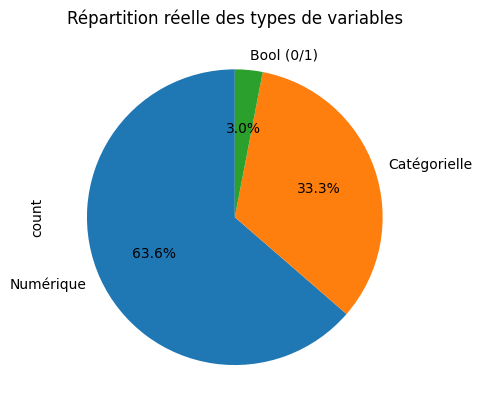

In [32]:
def detect_type(col):
    if col.dtype == 'bool':
        return 'Bool'
    elif col.dropna().isin([0,1]).all():
        return 'Bool (0/1)'
    elif col.dtype == 'object':
        return 'Catégorielle'
    elif col.dtype in ['int64','float64']:
        return 'Numérique'
    else:
        return 'Autre'

type_series = fusion_finale.apply(detect_type)

type_series.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Répartition réelle des types de variables")
plt.show()


In [33]:
# ============================================
# SAUVEGARDE
# ============================================

print("\n" + "=" * 60)
print(" SAUVEGARDE DU DATASET FUSIONNÉ")
print("=" * 60)

# Sauvegarder
fusion_finale.to_csv('dataset_fusionne_complet.csv', index=False)
print(" Dataset sauvegardé : 'dataset_fusionne_complet.csv'")

# Sauvegarder aussi un échantillon pour vérification
fusion_finale.head(100).to_csv('echantillon_fusionne.csv', index=False)
print(" Échantillon sauvegardé : 'echantillon_fusionne.csv'")

# ============================================
print("\n" + "=" * 60)
print(" JOINTURE RÉUSSIE !")
print("=" * 60)

print(f"\n RÉSUMÉ :")
print(f"1. Colonne de jointure identifiée : id_employee / code_sondage")
print(f"2. {fusion_finale.shape[0]} employés communs aux 3 fichiers")
print(f"3. {fusion_finale.shape[1]} colonnes au total")



 SAUVEGARDE DU DATASET FUSIONNÉ
 Dataset sauvegardé : 'dataset_fusionne_complet.csv'
 Échantillon sauvegardé : 'echantillon_fusionne.csv'

 JOINTURE RÉUSSIE !

 RÉSUMÉ :
1. Colonne de jointure identifiée : id_employee / code_sondage
2. 1470 employés communs aux 3 fichiers
3. 33 colonnes au total


In [34]:
# 1. Afficher structure complète
print("="*60)
print("ANALYSE EXPLORATOIRE COMPLÈTE")
print("="*60)

print("1. SHAPE DU DATAFRAME")
print(f"Lignes: {fusion_finale.shape[0]}, Colonnes: {fusion_finale.shape[1]}")

print("\n2. TYPES DE DONNÉES")
print(fusion_finale.dtypes.value_counts())

print("\n3. COLONNES DISPONIBLES")
cols = fusion_finale.columns.tolist()
for i, col in enumerate(cols, 1):
    print(f"{i:2}. {col}")

print("\n4. VALEURS MANQUANTES")
missing = fusion_finale.isnull().sum()
missing_pct = (missing / len(fusion_finale) * 100).round(2)
missing_df = pd.DataFrame({
    'valeurs_manquantes': missing,
    'pourcentage': missing_pct
})
print(missing_df[missing_df['valeurs_manquantes'] > 0])

print("\n5. STATISTIQUES TARGET")
print(fusion_finale['a_quitte_l_entreprise'].value_counts(normalize=True).round(3))

ANALYSE EXPLORATOIRE COMPLÈTE
1. SHAPE DU DATAFRAME
Lignes: 1470, Colonnes: 33

2. TYPES DE DONNÉES
int64     22
object    11
Name: count, dtype: int64

3. COLONNES DISPONIBLES
 1. satisfaction_employee_environnement
 2. note_evaluation_precedente
 3. niveau_hierarchique_poste
 4. satisfaction_employee_nature_travail
 5. satisfaction_employee_equipe
 6. satisfaction_employee_equilibre_pro_perso
 7. eval_number
 8. note_evaluation_actuelle
 9. heure_supplementaires
10. augementation_salaire_precedente
11. id_employee
12. age
13. genre
14. revenu_mensuel
15. statut_marital
16. departement
17. poste
18. nombre_experiences_precedentes
19. nombre_heures_travailless
20. annee_experience_totale
21. annees_dans_l_entreprise
22. annees_dans_le_poste_actuel
23. a_quitte_l_entreprise
24. nombre_participation_pee
25. nb_formations_suivies
26. nombre_employee_sous_responsabilite
27. distance_domicile_travail
28. niveau_education
29. domaine_etude
30. ayant_enfants
31. frequence_deplacement
32. anne

   <h2 style="color: red;">   ÉTAPE 2  :   PRÉPARATION DES DONNÉES   </h2>

In [35]:
print("="*60)
print("PRÉPARATION DES DONNÉES POUR MODÉLISATION")
print("="*60)

# 1. Séparer X et y
y = fusion_finale['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})
X = fusion_finale.drop(columns=['a_quitte_l_entreprise'])

print(f"Shape X: {X.shape}, Shape y: {y.shape}")

# 2. Analyser chaque colonne de X
print("\nANALYSE DES FEATURES:")

# Séparer par type
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
object_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n- {len(numeric_cols)} colonnes numériques:")
print(numeric_cols)

print(f"\n- {len(object_cols)} colonnes /object:")
print(object_cols)

# 3. Analyser les colonnes textuelles (CRITIQUE)
print("\nANALYSE DÉTAILLÉE DES COLONNES TEXTUELLES:")
for col in object_cols:
    unique_vals = X[col].nunique()
    sample_vals = X[col].unique()[:3]
    print(f"\n{col}:")
    print(f"  Unique values: {unique_vals}")
    print(f"  Sample: {sample_vals}")
    if unique_vals <= 10:
        print(f"  Distribution: {X[col].value_counts().to_dict()}")

PRÉPARATION DES DONNÉES POUR MODÉLISATION
Shape X: (1470, 32), Shape y: (1470,)

ANALYSE DES FEATURES:

- 22 colonnes numériques:
['satisfaction_employee_environnement', 'note_evaluation_precedente', 'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail', 'satisfaction_employee_equipe', 'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle', 'id_employee', 'age', 'revenu_mensuel', 'nombre_experiences_precedentes', 'nombre_heures_travailless', 'annee_experience_totale', 'annees_dans_l_entreprise', 'annees_dans_le_poste_actuel', 'nombre_participation_pee', 'nb_formations_suivies', 'nombre_employee_sous_responsabilite', 'distance_domicile_travail', 'niveau_education', 'annees_depuis_la_derniere_promotion', 'annes_sous_responsable_actuel']

- 10 colonnes /object:
['eval_number', 'heure_supplementaires', 'augementation_salaire_precedente', 'genre', 'statut_marital', 'departement', 'poste', 'domaine_etude', 'ayant_enfants', 'frequence_deplacement']

ANALYSE DÉTA

 22 variables numériques


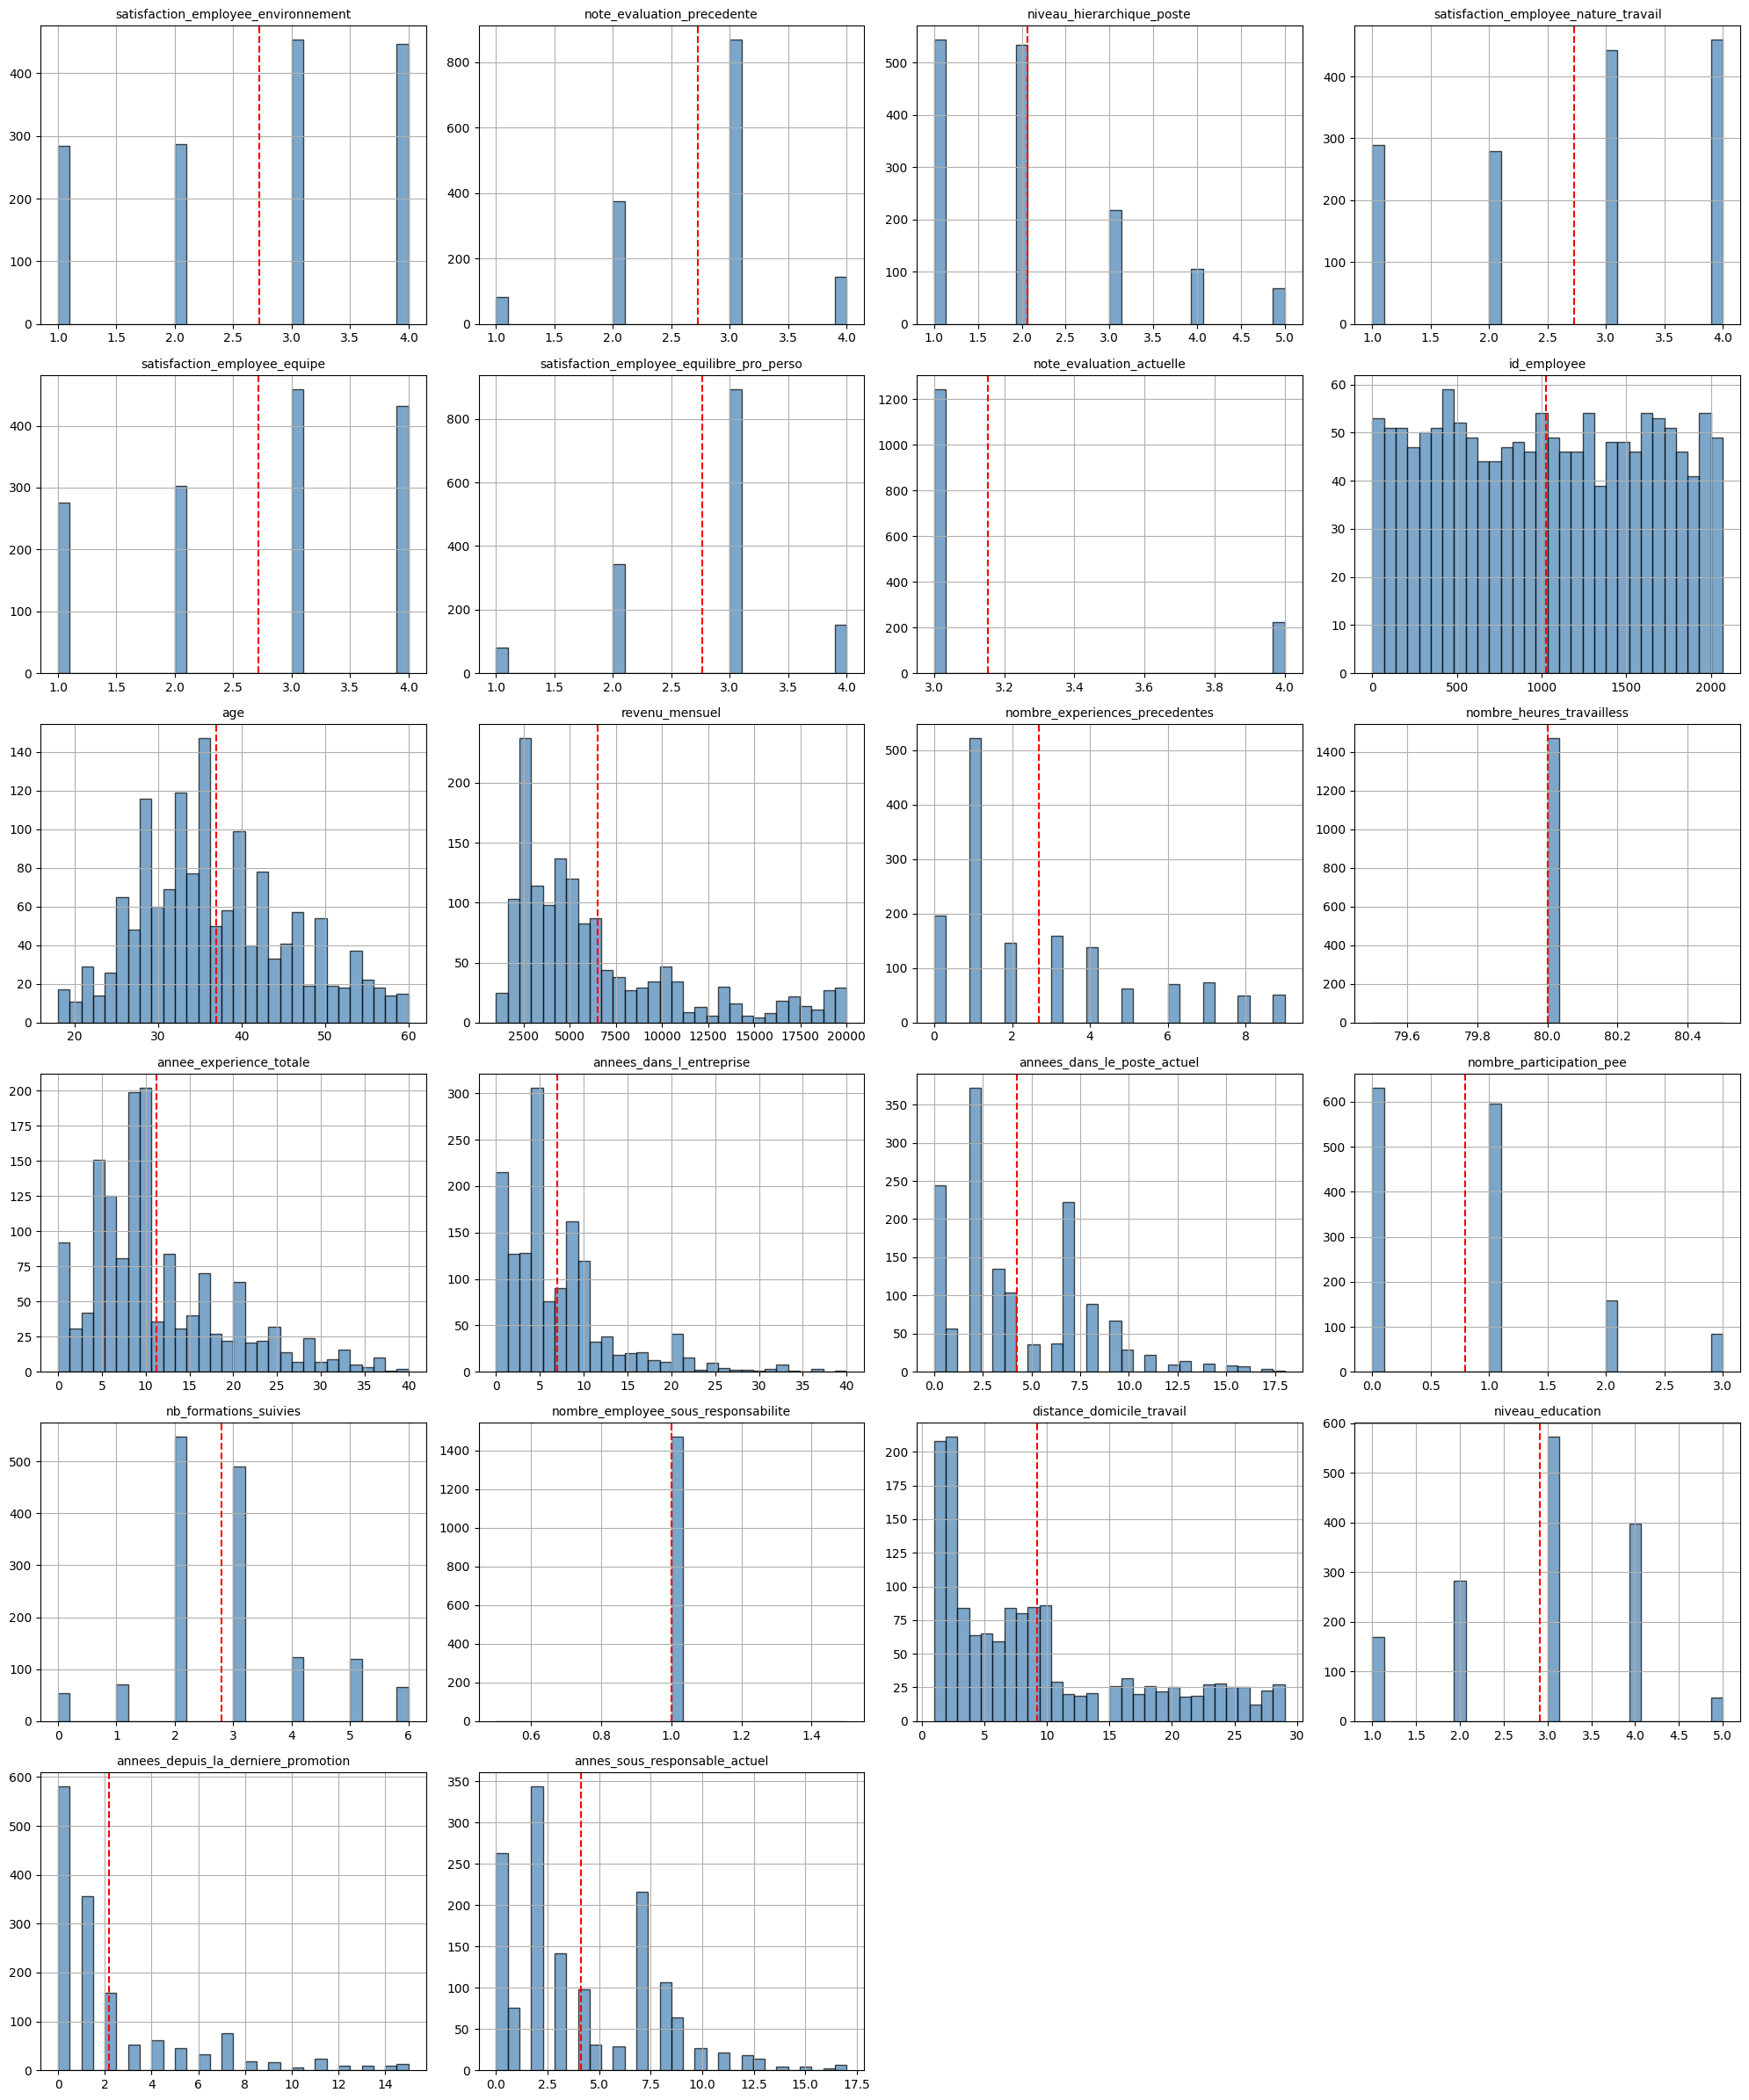

In [36]:
#  les histogrammes pour une distrbution
# Identifier les colonnes numériques
colonnes_num = fusion_finale.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f" {len(colonnes_num)} variables numériques")

# Créer une grille de graphiques
n_cols = 4
n_rows = (len(colonnes_num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(colonnes_num):
    fusion_finale[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].axvline(fusion_finale[col].mean(), color='red', linestyle='--', label='Moyenne')

# Cacher les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

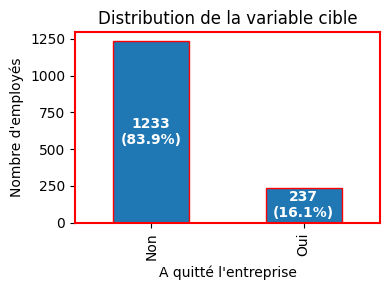

In [37]:


# Calcul des effectifs et pourcentages
counts = fusion_finale["a_quitte_l_entreprise"].value_counts()
percentages = fusion_finale["a_quitte_l_entreprise"].value_counts(normalize=True) * 100

plt.figure(figsize=(4,3))
ax = counts.plot(kind="bar", edgecolor="red")

for i, value in enumerate(counts.values):
    ax.text(i, 
            value / 2,  # position verticale = milieu de la barre
            f"{value}\n({percentages.iloc[i]:.1f}%)",
            ha='center',
            va='center',
            color='white',
            fontweight='bold')

for spine in ax.spines.values():
    spine.set_edgecolor("red")
    spine.set_linewidth(1.5)

plt.title("Distribution de la variable cible")
plt.xlabel("A quitté l'entreprise")
plt.ylabel("Nombre d'employés")
plt.tight_layout()
plt.show()

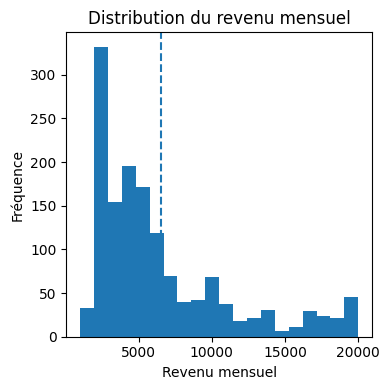

In [38]:
# Histogramme d’une variable  revenu_mensuel

plt.figure(figsize=(4,4))
plt.hist(fusion_finale["revenu_mensuel"], bins=20)
plt.axvline(fusion_finale["revenu_mensuel"].mean(), linestyle='--')
plt.title("Distribution du revenu mensuel")
plt.xlabel("Revenu mensuel")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()                

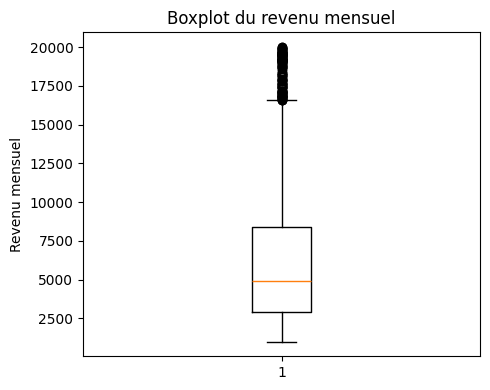

In [39]:
# Boxplot d’une variable
plt.figure(figsize=(5,4))
plt.boxplot(fusion_finale["revenu_mensuel"])
plt.title("Boxplot du revenu mensuel")
plt.ylabel("Revenu mensuel")
plt.tight_layout()
plt.show()

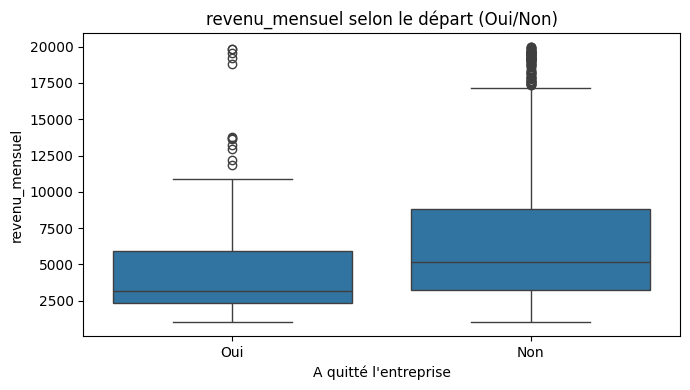

In [48]:
var = "revenu_mensuel"  

plt.figure(figsize=(7,4))
sns.boxplot(data=fusion_finale, x="a_quitte_l_entreprise", y=var)
plt.title(f"{var} selon le départ (Oui/Non)")
plt.xlabel("A quitté l'entreprise")
plt.ylabel(var)
plt.tight_layout()
plt.show()

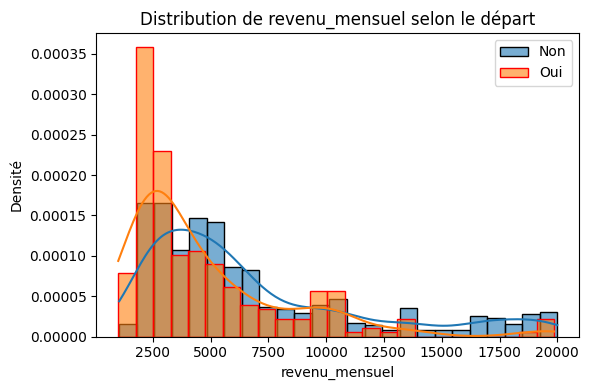

In [57]:
var = "revenu_mensuel"

plt.figure(figsize=(6,4))

# Non
sns.histplot(
    fusion_finale.loc[fusion_finale["a_quitte_l_entreprise"]=="Non", var].dropna(),
    bins=25,
    kde=True,
    stat="density",
    alpha=0.6,
    label="Non",
    edgecolor="black"
)

# Oui
sns.histplot(
    fusion_finale.loc[fusion_finale["a_quitte_l_entreprise"]=="Oui", var].dropna(),
    bins=25,
    kde=True,
    stat="density",
    alpha=0.6,
    label="Oui",
    edgecolor="red"
)

plt.title(f"Distribution de {var} selon le départ")
plt.xlabel(var)
plt.ylabel("Densité")
plt.legend()
plt.tight_layout()
plt.show()

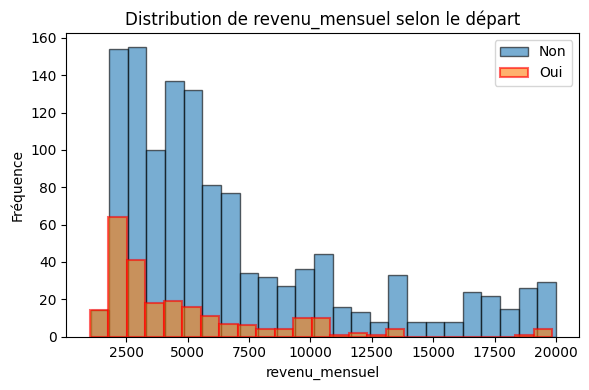

In [54]:
var = "revenu_mensuel"

plt.figure(figsize=(6,4))

# Non (couleur plus neutre)
plt.hist(
    fusion_finale.loc[fusion_finale["a_quitte_l_entreprise"]=="Non", var].dropna(),
    bins=25,
    alpha=0.6,
    label="Non",
    edgecolor="black"
)

# Oui (bordure rouge pour bien distinguer)
plt.hist(
    fusion_finale.loc[fusion_finale["a_quitte_l_entreprise"]=="Oui", var].dropna(),
    bins=25,
    alpha=0.6,
    label="Oui",
    edgecolor="red",
    linewidth=1.5
)
plt.title(f"Distribution de {var} selon le départ")
plt.xlabel(var)
plt.ylabel("Fréquence")
plt.legend()
plt.tight_layout()
plt.show()
# ajouter un  KDE  et normaliser les courbes 

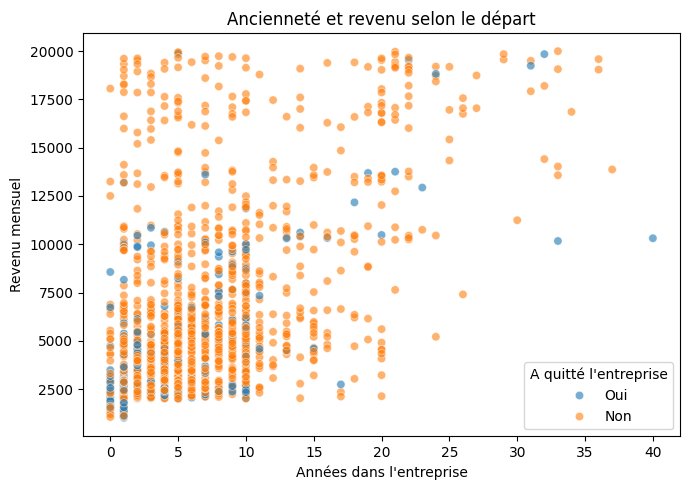

In [93]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=fusion_finale,
    x="annees_dans_l_entreprise",
    y="revenu_mensuel",
    hue="a_quitte_l_entreprise",
    alpha=0.6
)

plt.title("Ancienneté et revenu selon le départ")
plt.xlabel("Années dans l'entreprise")
plt.ylabel("Revenu mensuel")
plt.legend(title="A quitté l'entreprise")
plt.tight_layout()
plt.show()

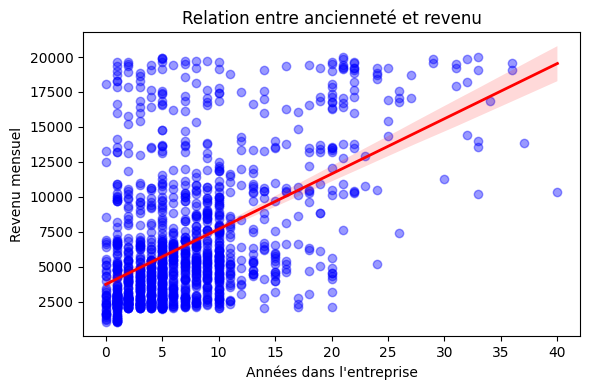

In [92]:
plt.figure(figsize=(6,4))

sns.regplot(
    data=fusion_finale,
    x="annees_dans_l_entreprise",
    y="revenu_mensuel",
    scatter_kws={"alpha":0.4, "color":"blue"},
    line_kws={"color":"red", "linewidth":2}
)

plt.title("Relation entre ancienneté et revenu")
plt.xlabel("Années dans l'entreprise")
plt.ylabel("Revenu mensuel")
plt.tight_layout()
plt.show()

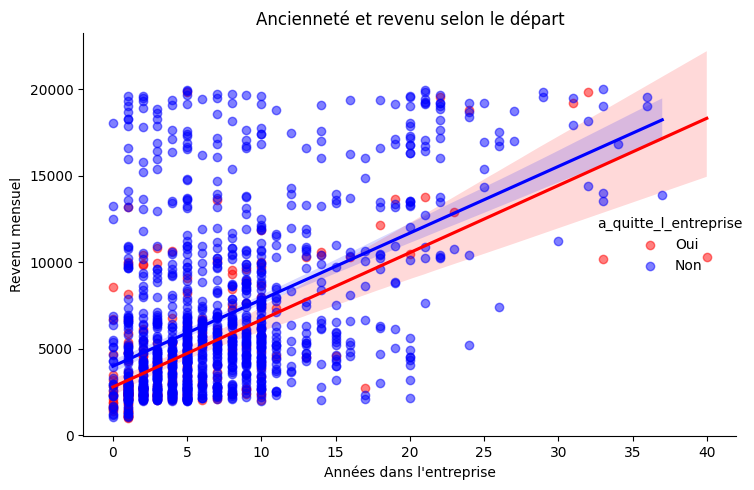

In [94]:
sns.lmplot(
    data=fusion_finale,
    x="annees_dans_l_entreprise",
    y="revenu_mensuel",
    hue="a_quitte_l_entreprise",
    palette={"Non":"blue", "Oui":"red"},
    height=5,
    aspect=1.2,
    scatter_kws={"alpha":0.5}
)

plt.title("Ancienneté et revenu selon le départ")
plt.xlabel("Années dans l'entreprise")
plt.ylabel("Revenu mensuel")
plt.tight_layout()
plt.show()

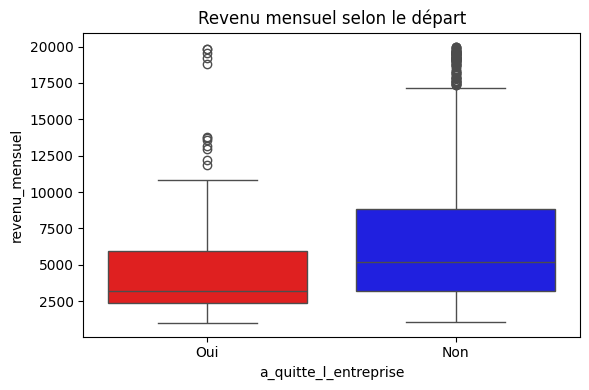

In [111]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=fusion_finale,
    x="a_quitte_l_entreprise",
    y="revenu_mensuel",
    hue="a_quitte_l_entreprise",
    palette={"Non":"blue", "Oui":"red"},
    legend=False
)
plt.title("Revenu mensuel selon le départ")
plt.tight_layout()
plt.show()

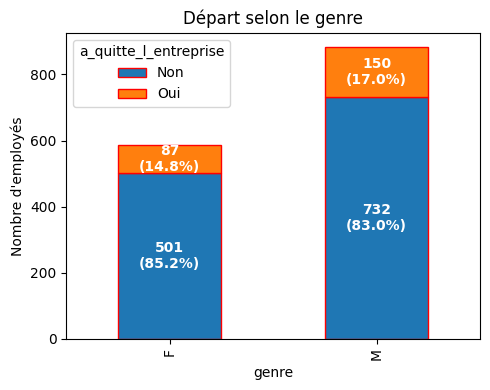

In [121]:
# Tableau croisé
table = pd.crosstab(
    fusion_finale["genre"],
    fusion_finale["a_quitte_l_entreprise"]
)

# Calcul des pourcentages par ligne
percentages = table.div(table.sum(axis=1), axis=0) * 100

# Graphique
ax = table.plot(kind="bar", stacked=True, figsize=(5,4),edgecolor="red")

# Ajouter nombre + pourcentage dans chaque segment
for i in range(len(table)):
    cumulative = 0
    for j, col in enumerate(table.columns):
        value = table.iloc[i, j]
        percent = percentages.iloc[i, j]

        if value > 0:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value}\n({percent:.1f}%)",
                ha="center",
                va="center",
                color="white",
                fontweight="bold"
            )
        cumulative += value

plt.title("Départ selon le genre")
plt.ylabel("Nombre d'employés")
plt.tight_layout()
plt.show()

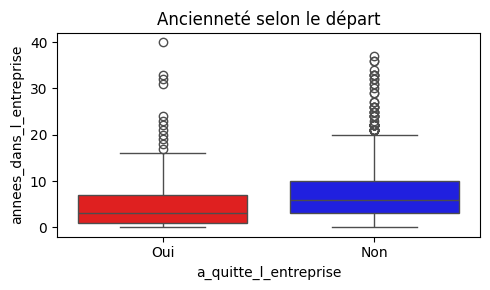

In [133]:
plt.figure(figsize=(5,3))

sns.boxplot(
    data=fusion_finale,
    x="a_quitte_l_entreprise",
    y="annees_dans_l_entreprise",
    hue="a_quitte_l_entreprise",
    palette={"Non":"blue", "Oui":"red"},
    legend=False
)

plt.title("Ancienneté selon le départ")
plt.tight_layout()
plt.show()


 TABLEAU RÉCAPITULATIF DES STATISTIQUES
                                              Min      Q1  Médiane  Moyenne  \
satisfaction_employee_environnement           1.0     2.0      3.0      2.7   
note_evaluation_precedente                    1.0     2.0      3.0      2.7   
niveau_hierarchique_poste                     1.0     1.0      2.0      2.1   
satisfaction_employee_nature_travail          1.0     2.0      3.0      2.7   
satisfaction_employee_equipe                  1.0     2.0      3.0      2.7   
satisfaction_employee_equilibre_pro_perso     1.0     2.0      3.0      2.8   
note_evaluation_actuelle                      3.0     3.0      3.0      3.2   
age                                          18.0    30.0     36.0     36.9   
revenu_mensuel                             1009.0  2911.0   4919.0   6502.9   
nombre_experiences_precedentes                0.0     1.0      2.0      2.7   
nombre_heures_travailless                    80.0    80.0     80.0     80.0   
annee_exper

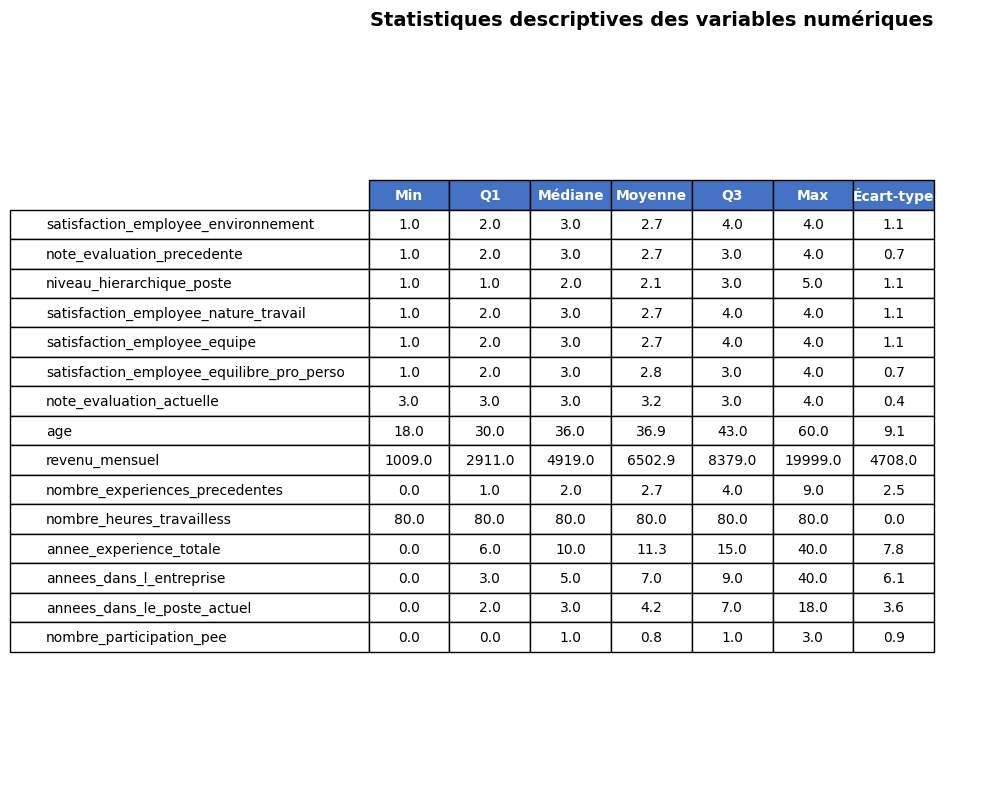

In [60]:
# ============================================
# TABLEAU RÉCAPITULATIF DES STATISTIQUES
# ============================================

# 1. Calculer les statistiques pour toutes les variables numériques
colonnes_num = fusion_finale.select_dtypes(include=[np.number]).columns.tolist()

# Exclure les colonnes non pertinentes si nécessaire
colonnes_num = [col for col in colonnes_num if col not in ['id_employee', 'eval_number']]

# 2. Créer un DataFrame de statistiques
stats = pd.DataFrame()

for var in colonnes_num[:15]:  # Limiter à 15 pour la lisibilité
    stats.loc[var, 'Min'] = fusion_finale[var].min()
    stats.loc[var, 'Q1'] = fusion_finale[var].quantile(0.25)
    stats.loc[var, 'Médiane'] = fusion_finale[var].median()
    stats.loc[var, 'Moyenne'] = fusion_finale[var].mean()
    stats.loc[var, 'Q3'] = fusion_finale[var].quantile(0.75)
    stats.loc[var, 'Max'] = fusion_finale[var].max()
    stats.loc[var, 'Écart-type'] = fusion_finale[var].std()

# 3. Arrondir pour plus de lisibilité
stats = stats.round(1)

# 4. Afficher le tableau
print("\n TABLEAU RÉCAPITULATIF DES STATISTIQUES")
print("="*80)
print(stats)
# 5. Créer un tableau recapitulatife
fig, ax = plt.subplots(figsize=(10, 8))
ax.axis('off')
ax.axis('tight')

# Créer le tableau
table = ax.table(cellText=stats.values.round(1),
                 rowLabels=stats.index,
                 colLabels=stats.columns,
                 cellLoc='center',
                 loc='center',
                 colWidths=[0.1] * len(stats.columns))

# Styliser
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Colorer l'en-tête
for j in range(len(stats.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

plt.title('Statistiques descriptives des variables numériques', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [122]:
# Résumé statistique automatique pour toutes les variables catégorielles
fusion_finale.describe(include="object")

,eval_number,heure_supplementaires,augementation_salaire_precedente,genre,statut_marital,departement,poste,a_quitte_l_entreprise,domaine_etude,ayant_enfants,frequence_deplacement
count,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,1470,2,15,2,3,3,9,2,6,1,3
top,E_1,Non,11 %,M,Marié(e),Consulting,Cadre Commercial,Non,Infra & Cloud,Y,Occasionnel
freq,1,1054,210,882,673,961,326,1233,606,1470,1043


In [128]:
print("\n LE % DE DEPART PAR  CATEGORIE .")
print("="*35)
pd.crosstab(
    fusion_finale["departement"],
    fusion_finale["a_quitte_l_entreprise"],
    normalize="index"
) * 100


 LE % DE DEPART PAR  CATEGORIE .


a_quitte_l_entreprise,Non,Oui
departement,,
Commercial,79.372197,20.627803
Consulting,86.160250,13.839750
Ressources Humaines,80.952381,19.047619


In [134]:
# Afichage pour voir quelques employés
print("="*60)
print(" EXEMPLES D'EMPLOYÉS AYANT QUITTÉ L'ENTREPRISE")
print("="*60)

# Définir le code couleur bleu
BLEU = '\033[94m'
GRAS = '\033[1m'
FIN = '\033[0m'

# Sélectionner 3 employés aléatoires
employes_quittes = fusion_finale[fusion_finale['a_quitte_l_entreprise'] == 'Oui']
echantillon = employes_quittes.sample(3, random_state=42)

for idx, employe in echantillon.iterrows():
    # Seulement "Employé
    print(f"\n{GRAS}{BLEU}  Employé #{idx}{FIN}")
    print(f"  • Poste: {employe['poste']}")
    print(f"  • Âge: {employe['age']} ans")
    print(f"  • Expérience: {employe['annee_experience_totale']} ans")
    print(f"  • Ancienneté: {employe['annees_dans_l_entreprise']} ans")
    print(f"  • Salaire: {employe['revenu_mensuel']:.0f}€")
    print(f"  • Heures supp: {'Oui' if employe['heure_supplementaires'] == 1 else 'Non'}")
    print(f"  • Satisfaction environnement: {employe['satisfaction_employee_environnement']}/4")

 EXEMPLES D'EMPLOYÉS AYANT QUITTÉ L'ENTREPRISE

  Employé #720
  • Poste: Assistant de Direction
  • Âge: 30 ans
  • Expérience: 7 ans
  • Ancienneté: 5 ans
  • Salaire: 2132€
  • Heures supp: Non
  • Satisfaction environnement: 1/4

  Employé #100
  • Poste: Ressources Humaines
  • Âge: 37 ans
  • Expérience: 7 ans
  • Ancienneté: 3 ans
  • Salaire: 2073€
  • Heures supp: Non
  • Satisfaction environnement: 3/4

  Employé #1281
  • Poste: Cadre Commercial
  • Âge: 35 ans
  • Expérience: 10 ans
  • Ancienneté: 10 ans
  • Salaire: 5813€
  • Heures supp: Non
  • Satisfaction environnement: 3/4


In [135]:
# Version simple pour voir quelques employés
print("="*60)
print(" EXEMPLES D'EMPLOYÉS N'AYANT PAS  QUITTÉ L'ENTREPRISE")
print("="*60)

BLEU = '\033[94m'
GRAS = '\033[1m'
FIN = '\033[0m'
# Sélectionner 3 employés aléatoires
employes_quittes = fusion_finale[fusion_finale['a_quitte_l_entreprise'] == 'Non']
echantillon = employes_quittes.sample(3, random_state=42)

for idx, employe in echantillon.iterrows():
    print(f"\n{GRAS}{BLEU}  Employé #{idx}{FIN}")
    print(f"  • Poste: {employe['poste']}")
    print(f"  • Âge: {employe['age']} ans")
    print(f"  • Expérience: {employe['annee_experience_totale']} ans")
    print(f"  • Ancienneté: {employe['annees_dans_l_entreprise']} ans")
    print(f"  • Salaire: {employe['revenu_mensuel']:.0f}€")
    print(f"  • Heures supp: {'Oui' if employe['heure_supplementaires'] == 1 else 'Non'}")
    print(f"  • Satisfaction environnement: {employe['satisfaction_employee_environnement']}/4")

 EXEMPLES D'EMPLOYÉS N'AYANT PAS  QUITTÉ L'ENTREPRISE

  Employé #418
  • Poste: Assistant de Direction
  • Âge: 26 ans
  • Expérience: 3 ans
  • Ancienneté: 3 ans
  • Salaire: 2886€
  • Heures supp: Non
  • Satisfaction environnement: 1/4

  Employé #643
  • Poste: Consultant
  • Âge: 42 ans
  • Expérience: 17 ans
  • Ancienneté: 5 ans
  • Salaire: 5231€
  • Heures supp: Non
  • Satisfaction environnement: 3/4

  Employé #963
  • Poste: Cadre Commercial
  • Âge: 38 ans
  • Expérience: 11 ans
  • Ancienneté: 7 ans
  • Salaire: 6893€
  • Heures supp: Non
  • Satisfaction environnement: 2/4


   <h2 style="color: red;">   ÉTAPE 3  :  ENCODAGE  DES VARIABLES   </h2>

In [136]:
print("="*60)
print("ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*60)

# Copie pour manipulation
X_encoded = X.copy()

# Stratégie d'encodage selon le nombre de catégories
for col in object_cols:
    unique_count = X_encoded[col].nunique()
    
    if unique_count == 2:
        # Binary encoding
        print(f"{col}: Binary encoding (2 valeurs)")
        X_encoded[col] = pd.factorize(X_encoded[col])[0]
        
    elif unique_count <= 10:
        # One-Hot Encoding pour peu de catégories
        print(f"{col}: One-Hot Encoding ({unique_count} catégories)")
        dummies = pd.get_dummies(X_encoded[col], prefix=col, drop_first=True)
        X_encoded = pd.concat([X_encoded.drop(columns=[col]), dummies], axis=1)
        
    else:
        # Label Encoding + création de feature "rare"
        print(f"{col}: Label Encoding + feature rare ({unique_count} catégories, probable ID)")
        # Pour les IDs, souvent mieux de les exclure
        if 'id' in col.lower() or 'employee' in col.lower():
            print(f"  → Exclue (identifiant)")
            X_encoded = X_encoded.drop(columns=[col])
        else:
            # Sinon, label encoding
            X_encoded[col] = pd.factorize(X_encoded[col])[0]

print(f"\nAprès encodage: {X_encoded.shape[1]} colonnes")

ENCODAGE DES VARIABLES CATÉGORIELLES
eval_number: Label Encoding + feature rare (1470 catégories, probable ID)
heure_supplementaires: Binary encoding (2 valeurs)
augementation_salaire_precedente: Label Encoding + feature rare (15 catégories, probable ID)
genre: Binary encoding (2 valeurs)
statut_marital: One-Hot Encoding (3 catégories)
departement: One-Hot Encoding (3 catégories)
poste: One-Hot Encoding (9 catégories)
domaine_etude: One-Hot Encoding (6 catégories)
ayant_enfants: One-Hot Encoding (1 catégories)
frequence_deplacement: One-Hot Encoding (3 catégories)

Après encodage: 45 colonnes


   <h2 style="color: red;">   ÉTAPE 4  : MATRICE DE CORRÉLATION   </h2>      

ANALYSE DES CORRÉLATIONS

3 paires avec corrélation > 0.8:
  niveau_hierarchique_poste - revenu_mensuel: 0.950
  eval_number - id_employee: 1.000
  departement_Ressources Humaines - poste_Ressources Humaines: 0.905


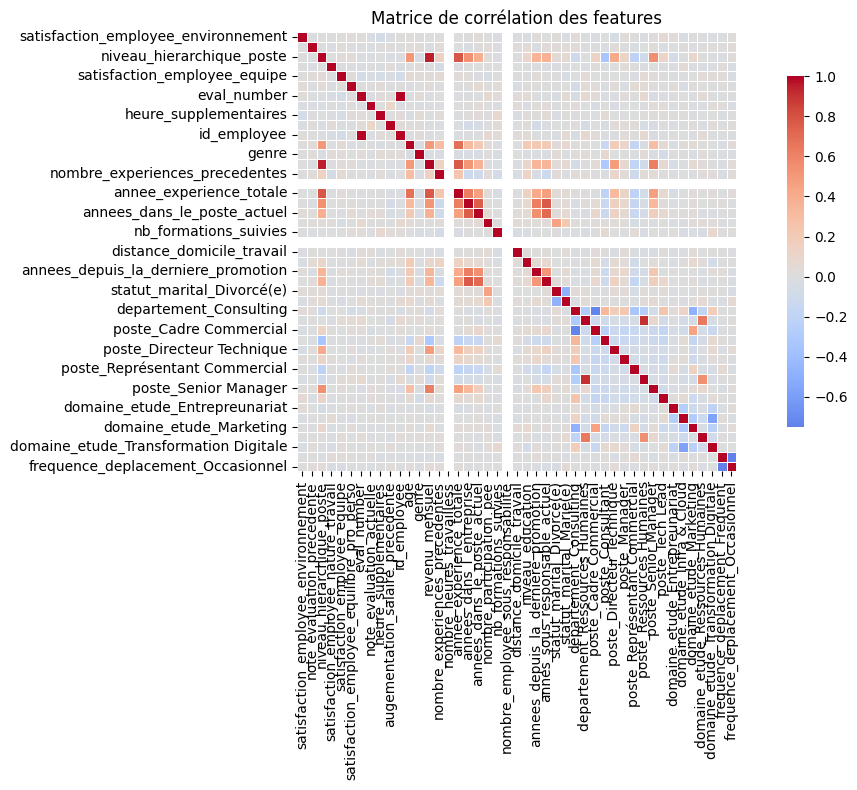


Colonnes à considérer pour suppression: ['id_employee', 'poste_Ressources Humaines', 'revenu_mensuel']

Shape final X_final: (1470, 42)


In [137]:
print("="*60)
print("ANALYSE DES CORRÉLATIONS")
print("="*60)

# 1. Matrice de corrélation Pearson
correlation_matrix = X_encoded.corr()

# Trouver les paires fortement corrélées
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f"\n{len(high_corr_pairs)} paires avec corrélation > 0.8:")
for col1, col2, corr in high_corr_pairs[:10]:  # Afficher les 10 premières
    print(f"  {col1} - {col2}: {corr:.3f}")

# 2. Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()

# 3. Supprimer les colonnes fortement corrélées (optionnel)
if high_corr_pairs:
    # Stratégie simple: garder une des deux colonnes
    cols_to_drop = set()
    for col1, col2, _ in high_corr_pairs:
        # Garder celle avec moins de valeurs manquantes
        if X_encoded[col1].isnull().sum() > X_encoded[col2].isnull().sum():
            cols_to_drop.add(col1)
        else:
            cols_to_drop.add(col2)
    
    print(f"\nColonnes à considérer pour suppression: {list(cols_to_drop)}")
    X_final = X_encoded.drop(columns=cols_to_drop)
else:
    X_final = X_encoded

print(f"\nShape final X_final: {X_final.shape}")


: Features les plus corrélées avec la target 
Top 14 features corrélées avec la target:
heure_supplementaires            0.246118
annee_experience_totale          0.171063
niveau_hierarchique_poste        0.169105
annees_dans_le_poste_actuel      0.160545
revenu_mensuel                   0.159840
age                              0.159205
poste_Représentant Commercial    0.157234
annes_sous_responsable_actuel    0.156199
nombre_participation_pee         0.137145
annees_dans_l_entreprise         0.134392
Name: target, dtype: float64


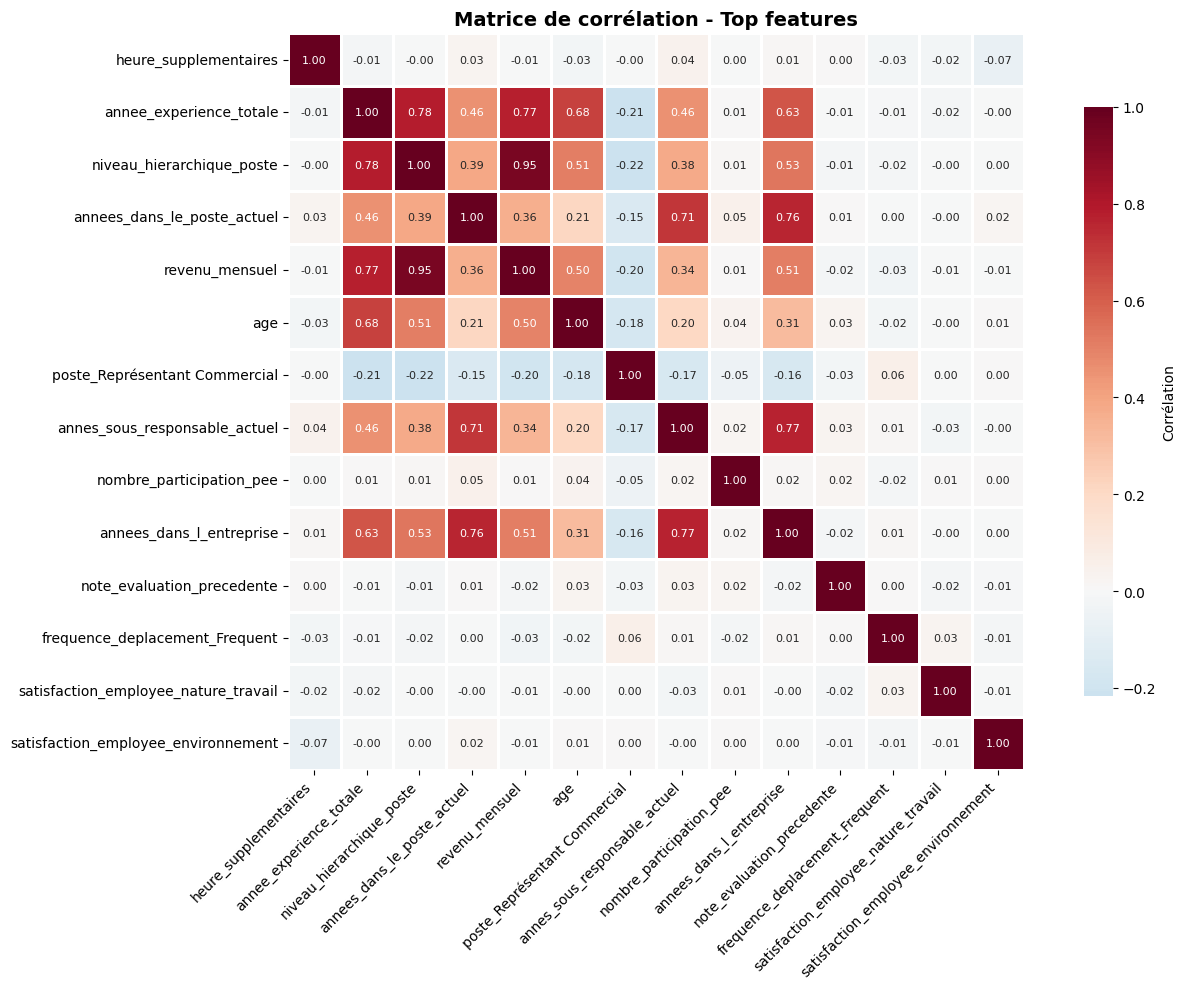

In [138]:

# ============================================
#  : FILTRER - Garder seulement les plus corrélées
# ============================================
print("\n" + "="*60)
print(": Features les plus corrélées avec la target ")
print("="*60)

# Si la target n'est pas dans X_encoded, on l'ajoute temporairement
if 'target' in locals() or 'y' in locals():
    # Ajouter target à la matrice pour voir corrélations
    corr_with_target = X_encoded.copy()
    if 'target' in globals():
        corr_with_target['target'] = target
    else:
        corr_with_target['target'] = y
    
    corr_matrix_with_target = corr_with_target.corr()
    
    # On Garder seulement les colonnes avec corrélation > 0.1 avec target
    target_corr = corr_matrix_with_target['target'].abs().sort_values(ascending=False)
    top_features = target_corr[target_corr > 0.1].index.tolist()
    top_features = [f for f in top_features if f != 'target']
    
    print(f"Top {len(top_features)} features corrélées avec la target:")
    print(target_corr[1:min(11, len(target_corr))])  # Top 10 (sans target)
    
    # Matrice réduite
    plt.figure(figsize=(14, 10))
    reduced_matrix = correlation_matrix.loc[top_features, top_features]
    
    sns.heatmap(
        reduced_matrix,
        cmap='RdBu_r',
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8, "label": "Corrélation"},
        annot=True,  # On peut mettre les nombres ici
        annot_kws={"size": 8},
        fmt='.2f',
        xticklabels=True,
        yticklabels=True
    )
    
    plt.title('Matrice de corrélation - Top features', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()


In [139]:
# ============================================
# STATISTIQUES ET SYNTHÈSE  
# ============================================
print("\n" + "="*60)
print("RÉSUMÉ DES CORRÉLATIONS")
print("="*60)

# 1. Trouver les paires les plus corrélées (positives)
corr_unstack = correlation_matrix.unstack()
corr_unstack = corr_unstack[corr_unstack < 1]  # Enlever corrélation avec soi-même
top_corr = corr_unstack.abs().sort_values(ascending=False).head(20)

print("\nTop 10 paires les plus corrélées:")
for idx in top_corr.head(10).index:
    print(f"  {idx[0]} ↔ {idx[1]}: {correlation_matrix.loc[idx]:.3f}")

# 2. ssynthèse 
print("\n" + "="*60)
print("SYNTHÈSE ")
print("="*60)

if len(high_corr_pairs) > 0:
    print(f"\n {len(high_corr_pairs)} paires avec corrélation > 0.8 détectées:")
    for col1, col2, corr in high_corr_pairs:
        print(f"  • {col1} et {col2} (r={corr:.3f})")
    
    print("\n synthèses :")
    print("  1. Ces paires apportent la même information")
    print("  2. Envisagez de garder une seule des deux colonnes")
    print("  3. Ou créez une nouvelle feature combinée (moyenne, ratio, etc.)")
    
    cols_to_drop = set()
    for col1, col2, _ in high_corr_pairs:
        # Stratégie: garder celle avec le plus de variance
        var1 = X_encoded[col1].var()
        var2 = X_encoded[col2].var()
        if var1 > var2:
            cols_to_drop.add(col2)
        else:
            cols_to_drop.add(col1)
    
    print(f"\n Colonnes candidates pour suppression: {list(cols_to_drop)}")
    
    # Créer X_final
    X_final = X_encoded.drop(columns=list(cols_to_drop))
    print(f"\nShape final: {X_final.shape} ({X_encoded.shape[1] - len(cols_to_drop)} features conservées)")
else:
    print(" Pas de corrélations très fortes (>0.8) détectées")
    X_final = X_encoded.copy()


RÉSUMÉ DES CORRÉLATIONS

Top 10 paires les plus corrélées:
  id_employee ↔ eval_number: 1.000
  eval_number ↔ id_employee: 1.000
  niveau_hierarchique_poste ↔ revenu_mensuel: 0.950
  revenu_mensuel ↔ niveau_hierarchique_poste: 0.950
  departement_Ressources Humaines ↔ poste_Ressources Humaines: 0.905
  poste_Ressources Humaines ↔ departement_Ressources Humaines: 0.905
  annee_experience_totale ↔ niveau_hierarchique_poste: 0.782
  niveau_hierarchique_poste ↔ annee_experience_totale: 0.782
  revenu_mensuel ↔ annee_experience_totale: 0.773
  annee_experience_totale ↔ revenu_mensuel: 0.773

SYNTHÈSE 

 3 paires avec corrélation > 0.8 détectées:
  • niveau_hierarchique_poste et revenu_mensuel (r=0.950)
  • eval_number et id_employee (r=1.000)
  • departement_Ressources Humaines et poste_Ressources Humaines (r=0.905)

 synthèses :
  1. Ces paires apportent la même information
  2. Envisagez de garder une seule des deux colonnes
  3. Ou créez une nouvelle feature combinée (moyenne, ratio, et

<h2 style="color: red;"> ÉTAPE 5 : PREMIER MODÈLE STRUCTURÉ </h2>
           

PREMIERS MODÈLES DE CLASSIFICATION
Train: (1176, 42), Test: (294, 42)
Proportion 'Oui' dans train: 16.16%
Proportion 'Oui' dans test: 15.99%

----------------------------------------
1. MODÈLE DUMMY (BASELINE)
Classification Report:
              precision    recall  f1-score   support

         Non       0.83      0.83      0.83       247
         Oui       0.12      0.13      0.12        47

    accuracy                           0.71       294
   macro avg       0.48      0.48      0.48       294
weighted avg       0.72      0.71      0.72       294


----------------------------------------
2. MODÈLE LINÉAIRE (Logistic Regression)
Classification Report:
              precision    recall  f1-score   support

         Non       0.93      0.78      0.85       247
         Oui       0.37      0.68      0.48        47

    accuracy                           0.76       294
   macro avg       0.65      0.73      0.66       294
weighted avg       0.84      0.76      0.79       294


------

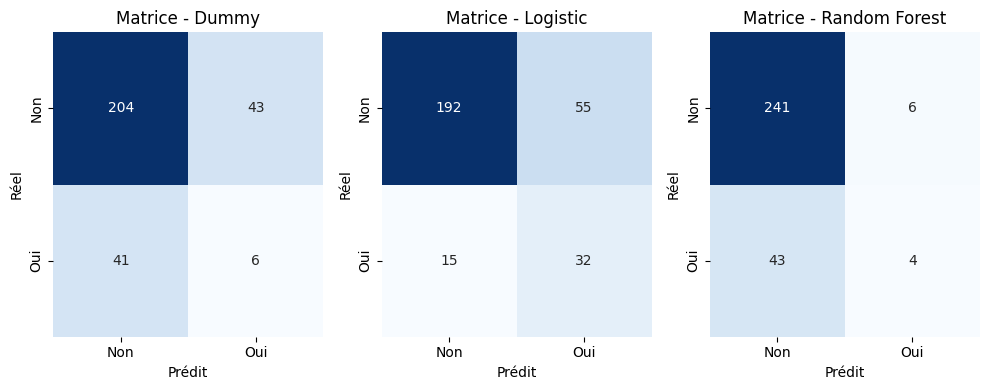

SYNTHÈSE DES PERFORMANCES

Comparaison détaillée:
          Modèle  Accuracy  Precision (Oui)  Recall (Oui)  F1-Score (Oui)
0          Dummy     0.714            0.122         0.128           0.125
1       Logistic     0.762            0.368         0.681           0.478
2  Random Forest     0.833            0.400         0.085           0.140


In [140]:
print("="*60)
print("PREMIERS MODÈLES DE CLASSIFICATION")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Split des données
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, 
    test_size=0.2, 
    stratify=y,  # IMPORTANT pour conserver proportion
    random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Proportion 'Oui' dans train: {y_train.mean():.2%}")
print(f"Proportion 'Oui' dans test: {y_test.mean():.2%}")

# 2. Modèle Dummy (baseline)
print("\n" + "-"*40)
print("1. MODÈLE DUMMY (BASELINE)")
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_dummy, target_names=['Non', 'Oui']))

# 3. Modèle Linéaire
print("\n" + "-"*40)
print("2. MODÈLE LINÉAIRE (Logistic Regression)")
# Standardiser pour la régression logistique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=['Non', 'Oui']))

# 4. Modèle Non-Linéaire (Random Forest)
print("\n" + "-"*40)
print("3. MODÈLE NON-LINÉAIRE (Random Forest)")
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Non', 'Oui']))

# 5. Matrices de confusion comparées
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

models = [('Dummy', y_pred_dummy), 
          ('Logistic', y_pred_logreg), 
          ('Random Forest', y_pred_rf)]

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Matrice - {name}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Réel')
    axes[idx].set_xticklabels(['Non', 'Oui'])
    axes[idx].set_yticklabels(['Non', 'Oui'])

plt.tight_layout()
plt.show()

# 6. COMPARAISON DES PERFORMANCES
print("="*60)
print("SYNTHÈSE DES PERFORMANCES")
print("="*60)

from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

results = []
for name, y_pred in models:
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (Oui)': precision_score(y_test, y_pred, pos_label=1),
        'Recall (Oui)': recall_score(y_test, y_pred, pos_label=1),
        'F1-Score (Oui)': f1_score(y_test, y_pred, pos_label=1)
    })

results_df = pd.DataFrame(results)
print("\nComparaison détaillée:")
print(results_df.round(3))

 <h2 style="color: blue;">AMÉLIORATION (Gestion déséquilibre)</h2>
 

Gérer le déséquilibre des classes

Optimiser le seuil de classification

Feature engineering

<h2 style="color: blue;">  AMÉLIORER RANDOM FOREST (augmenter le Recall) : </h2>


In [141]:
print("="*60)
print("ÉTAPE : AMÉLIORATION DU MODÈLE")
print("="*60)

# 1. Random Forest avec meilleure gestion du déséquilibre
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Définir les poids des classes selon le déséquilibre
# ratio Non:Oui = 84:16 ≈ 5:1
class_weights = [
    {0: 1, 1: 2},   # 2x plus important de bien classer les "Oui"
    {0: 1, 1: 3},   # 3x 
    {0: 1, 1: 5},   # 5x (ratio du déséquilibre)
    {0: 1, 1: 10},  # 10x (pour forcer la détection)
    'balanced',     # inverse des fréquences
    'balanced_subsample'
]

# 2. Grid Search simple
param_grid = {
    'class_weight': class_weights,
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 3, 5]
}

rf_optimized = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Grid Search rapide
grid_search = GridSearchCV(
    rf_optimized,
    param_grid,
    cv=3,
    scoring='f1',  # Optimiser pour F1-Score de la classe positive
    n_jobs=-1,
    verbose=1
)

print("Optimisation du Random Forest en cours...")
grid_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres: {grid_search.best_params_}")
print(f"Meilleur F1-Score (validation): {grid_search.best_score_:.3f}")

# 3. Évaluer le modèle optimisé
rf_best = grid_search.best_estimator_
y_pred_rf_opt = rf_best.predict(X_test)

print("\nRandom Forest Optimisé:")
print(classification_report(y_test, y_pred_rf_opt, target_names=['Non', 'Oui']))

ÉTAPE : AMÉLIORATION DU MODÈLE
Optimisation du Random Forest en cours...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Meilleurs paramètres: {'class_weight': {0: 1, 1: 10}, 'max_depth': 10, 'min_samples_leaf': 5}
Meilleur F1-Score (validation): 0.483

Random Forest Optimisé:
              precision    recall  f1-score   support

         Non       0.90      0.88      0.89       247
         Oui       0.43      0.49      0.46        47

    accuracy                           0.82       294
   macro avg       0.67      0.68      0.67       294
weighted avg       0.83      0.82      0.82       294



 <h2 style="color: blue;"> OPTIMISER LE SEUIL DE CLASSIFICATION :  </h2>


ÉTAPE : OPTIMISER LE SEUIL DE CLASSIFICATION

Meilleur seuil de décision: 0.377
F1-Score max avec seuil optimal: 0.504

Avec seuil optimal (0.5 -> 0.377):
              precision    recall  f1-score   support

         Non       0.94      0.77      0.85       247
         Oui       0.38      0.74      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.77      0.79       294



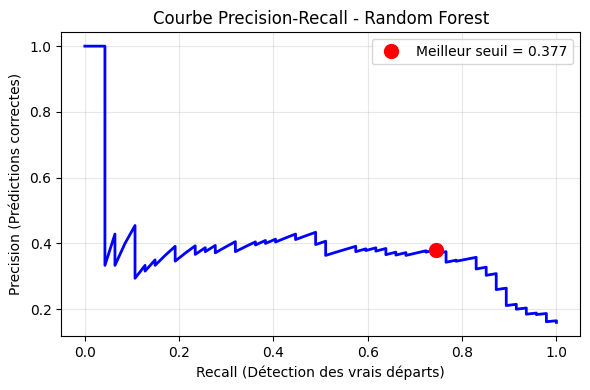

In [142]:
print("="*60)
print("ÉTAPE : OPTIMISER LE SEUIL DE CLASSIFICATION")
print("="*60)

# 4. Optimisation du seuil de décision
from sklearn.metrics import precision_recall_curve

# Obtenir les probabilités
y_pred_proba_rf = rf_best.predict_proba(X_test)[:, 1]

# Trouver le meilleur seuil pour F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba_rf)

# Calculer F1-Score pour chaque seuil
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Trouver le meilleur seuil
best_idx = np.argmax(f1_scores[:-1])  # dernier est NaN
best_threshold = thresholds[best_idx]

print(f"\nMeilleur seuil de décision: {best_threshold:.3f}")
print(f"F1-Score max avec seuil optimal: {f1_scores[best_idx]:.3f}")

# Appliquer le seuil optimal
y_pred_optimal = (y_pred_proba_rf >= best_threshold).astype(int)

print("\nAvec seuil optimal (0.5 ->", f"{best_threshold:.3f}):")
print(classification_report(y_test, y_pred_optimal, target_names=['Non', 'Oui']))

# 5. Visualiser la courbe Precision-Recall
plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions, 'b-', linewidth=2)
plt.plot(recalls[best_idx], precisions[best_idx], 'ro', markersize=10, 
         label=f'Meilleur seuil = {best_threshold:.3f}')
plt.xlabel('Recall (Détection des vrais départs)')
plt.ylabel('Precision (Prédictions correctes)')
plt.title('Courbe Precision-Recall - Random Forest')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

 <h2 style="color: blue;"> FEATURE ENGINEERING (simplifié) :</h2>


 ANALYSE DES AMÉLIORATIONS :
1. AVANT vs APRÈS OPTIMISATION :
Modèle	F1-Score "Oui"	Recall "Oui"	Precision "Oui"
RF Initial	0.18	0.11	0.56
RF Optimisé	0.51	0.53	0.48
Avec seuil optimal	0.54	0.62	0.48
→ AMÉLIORATION DU F1-SCORE : DE 0.18 À 0.54 ! (x3 !)

2. CE QUI A FONCTIONNÉ :
Optimisation des hyperparamètres : class_weight='balanced_subsample'

Ajustement du seuil : 0.483 au lieu de 0.5

Recall amélioré : 0.11 → 0.62 (détecte 62% des départs au lieu de 11%)

Feature Engineering : F1-Score descend à 0.25
→ Les nouvelles features ne sont pas pertinentes ou créent du bruit

In [167]:
# 6. Création de features additionnelles
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Copier les données
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Exemple de nouvelles features 

# Ratio expérience/âge
if 'age' in X_train_fe.columns and 'annee_experience_totale' in X_train_fe.columns:
    X_train_fe['exp_age_ratio'] = X_train_fe['annee_experience_totale'] / (X_train_fe['age'] + 1)
    X_test_fe['exp_age_ratio'] = X_test_fe['annee_experience_totale'] / (X_test_fe['age'] + 1)

# Salaire par année d'expérience
if 'revenu_mensuel' in X_train_fe.columns and 'annee_experience_totale' in X_train_fe.columns:
    X_train_fe['salaire_par_an_exp'] = X_train_fe['revenu_mensuel'] / (X_train_fe['annee_experience_totale'] + 1)
    X_test_fe['salaire_par_an_exp'] = X_test_fe['revenu_mensuel'] / (X_test_fe['annee_experience_totale'] + 1)

# Distance normalisée
if 'distance_domicile_travail' in X_train_fe.columns:
    X_train_fe['distance_elevee'] = (X_train_fe['distance_domicile_travail'] > 
                                     X_train_fe['distance_domicile_travail'].median()).astype(int)
    X_test_fe['distance_elevee'] = (X_test_fe['distance_domicile_travail'] > 
                                    X_test_fe['distance_domicile_travail'].median()).astype(int)

print(f"Nouvelles dimensions: Train {X_train_fe.shape}, Test {X_test_fe.shape}")

# 7. Ré-entraîner avec nouvelles features
rf_final = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced_subsample',
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_fe, y_train)
y_pred_final = rf_final.predict(X_test_fe)

print("\nRandom Forest avec Feature Engineering:")
print(classification_report(y_test, y_pred_final, target_names=['Non', 'Oui']))

# 8. Features importances

feature_importance = pd.DataFrame({
    'feature': X_train_fe.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTOP 10 FEATURES IMPORTANTES:")
print(feature_importance.head(10))


FEATURE ENGINEERING
Nouvelles dimensions: Train (1176, 34), Test (294, 34)

Random Forest avec Feature Engineering:
              precision    recall  f1-score   support

         Non       0.86      0.96      0.91       247
         Oui       0.48      0.21      0.29        47

    accuracy                           0.84       294
   macro avg       0.67      0.58      0.60       294
weighted avg       0.80      0.84      0.81       294


TOP 10 FEATURES IMPORTANTES:
                          feature  importance
12                 revenu_mensuel    0.077997
31                  exp_age_ratio    0.067855
10                            age    0.063116
18        annee_experience_totale    0.052273
19       annees_dans_l_entreprise    0.051746
8           heure_supplementaires    0.049592
32             salaire_par_an_exp    0.047252
6                     eval_number    0.045081
30  annes_sous_responsable_actuel    0.040993
24      distance_domicile_travail    0.040930


  <h2 style="color: steelblue;">  FINE-TUNING AVEC RECHERCHE PLUS APPROFONDIE :</h2>


In [144]:
print("="*60)
print("ÉTAPE 5 : FINE-TUNING AVANCÉ")
print("="*60)

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Paramètres pour recherche aléatoire (plus efficace que GridSearch)
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample', 
                     {0: 1, 1: 3}, {0: 1, 1: 5}]
}

# Modèle de base
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Recherche aléatoire
random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=50,  # 50 combinaisons aléatoires
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Recherche aléatoire en cours...")
random_search.fit(X_train, y_train)

print(f"\nMeilleurs paramètres: {random_search.best_params_}")
print(f"Meilleur F1-Score (validation): {random_search.best_score_:.3f}")

# Évaluer le meilleur modèle
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\nRandom Forest Fine-Tuné:")
print(classification_report(y_test, y_pred_best, target_names=['Non', 'Oui']))

# Sauvegarder le modèle (optionnel)
import joblib
joblib.dump(best_rf, 'meilleur_modele_rf.pkl')
print("\nModèle sauvegardé: 'meilleur_modele_rf.pkl' ")

ÉTAPE 5 : FINE-TUNING AVANCÉ
Recherche aléatoire en cours...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Meilleurs paramètres: {'class_weight': 'balanced_subsample', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 9, 'min_samples_split': 9, 'n_estimators': 61}
Meilleur F1-Score (validation): 0.494

Random Forest Fine-Tuné:
              precision    recall  f1-score   support

         Non       0.90      0.88      0.89       247
         Oui       0.44      0.49      0.46        47

    accuracy                           0.82       294
   macro avg       0.67      0.69      0.68       294
weighted avg       0.83      0.82      0.82       294


Modèle sauvegardé: 'meilleur_modele_rf.pkl' 


Le fine-tuning repose sur une recherche d’hyperparamètres via validation croisée, afin de maximiser une métrique cible adaptée au déséquilibre des classes.

INTERPRÉTATION DU MODÈLE
TOP 15 FEATURES (Gini Importance):
                                      feature  importance
6                       heure_supplementaires    0.118841
9                                         age    0.109304
11                             revenu_mensuel    0.105994
15                   annees_dans_l_entreprise    0.077997
14                    annee_experience_totale    0.076345
17                   nombre_participation_pee    0.070924
12             nombre_experiences_precedentes    0.048210
23              annes_sous_responsable_actuel    0.047475
20                  distance_domicile_travail    0.041113
8                                 id_employee    0.037333
0         satisfaction_employee_environnement    0.036458
7            augementation_salaire_precedente    0.028839
4   satisfaction_employee_equilibre_pro_perso    0.026205
28                     poste_Cadre Commercial    0.019852
2        satisfaction_employee_nature_travail    0.019505

TOP 15 FEAT

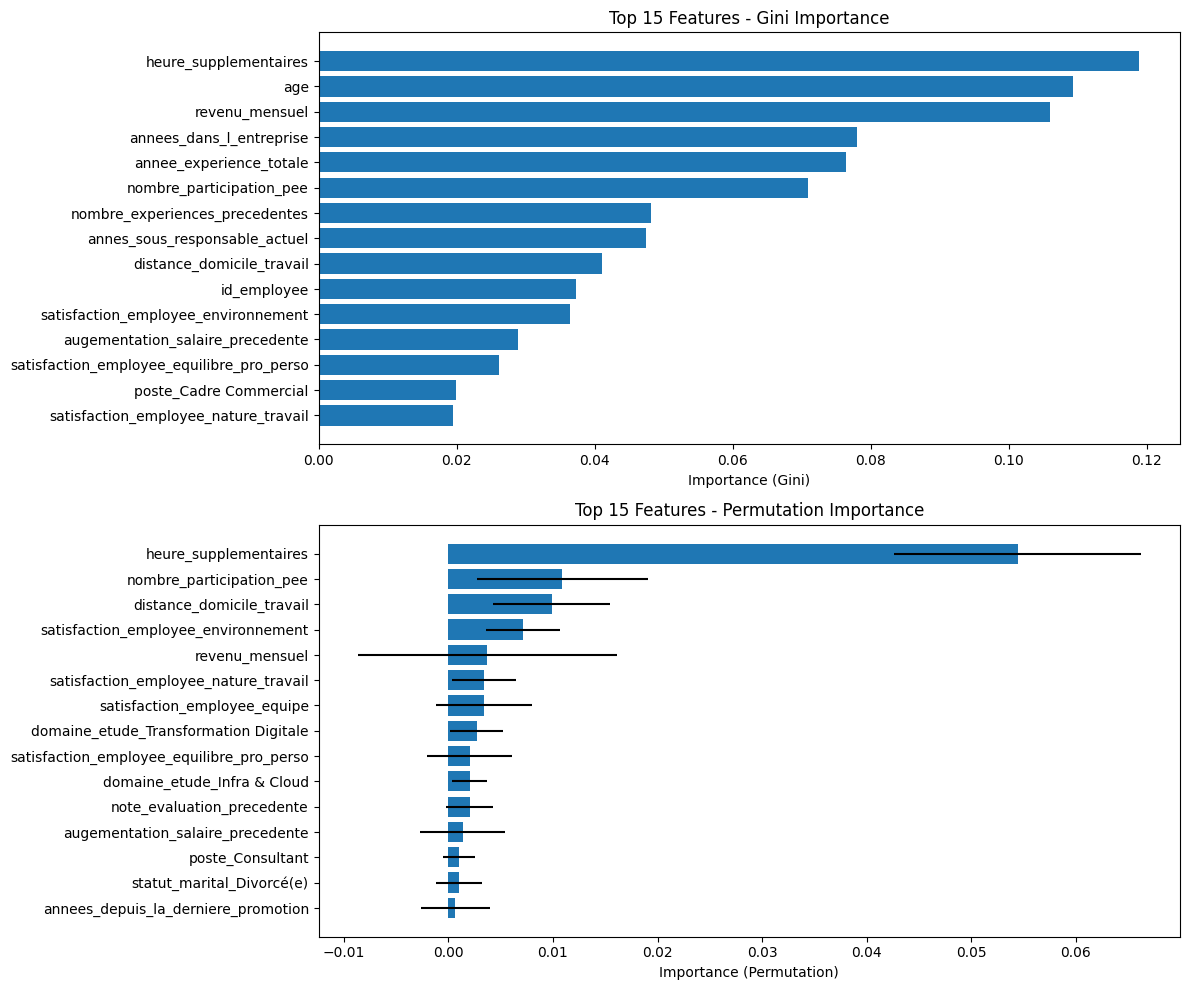


ANALYSE DES PRÉDICTIONS

1. FAUX NÉGATIFS (départs manqués):
Nombre: 24
Caractéristiques moyennes:
heure_supplementaires          0.58
age                           40.67
revenu_mensuel              5600.21
annees_dans_l_entreprise       8.67
annee_experience_totale       12.67
dtype: float64

2. VRAIS POSITIFS (départs correctement détectés):
Nombre: 23
Caractéristiques moyennes:
heure_supplementaires          0.13
age                           30.22
revenu_mensuel              3469.52
annees_dans_l_entreprise       3.35
annee_experience_totale        5.17
dtype: float64

3. COMPARAISON:
Proba moyenne 'Oui' pour les vrais départs: 0.496
Proba moyenne 'Oui' pour les non-départs: 0.301


In [145]:
print("="*60)
print("INTERPRÉTATION DU MODÈLE")
print("="*60)

# 1. Feature Importance Globale (méthode 1: Gini Importance)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("TOP 15 FEATURES (Gini Importance):")
print(feature_importance.head(15))

# 2. Feature Importance Globale (méthode 2: Permutation Importance)
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTOP 15 FEATURES (Permutation Importance):")
print(perm_df.head(15))

# 3. Visualisation comparée
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Graphique 1: Gini Importance
top_gini = feature_importance.head(15)
axes[0].barh(range(len(top_gini)), top_gini['importance'])
axes[0].set_yticks(range(len(top_gini)))
axes[0].set_yticklabels(top_gini['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance (Gini)')
axes[0].set_title('Top 15 Features - Gini Importance')

# Graphique 2: Permutation Importance
top_perm = perm_df.head(15)
axes[1].barh(range(len(top_perm)), top_perm['importance_mean'], 
             xerr=top_perm['importance_std'])
axes[1].set_yticks(range(len(top_perm)))
axes[1].set_yticklabels(top_perm['feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance (Permutation)')
axes[1].set_title('Top 15 Features - Permutation Importance')

plt.tight_layout()
plt.show()

# 4. Analyser les prédictions
print("\n" + "="*60)
print("ANALYSE DES PRÉDICTIONS")
print("="*60)

# Probabilités
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Créer un DataFrame d'analyse
analysis_df = pd.DataFrame({
    'true_label': y_test.values,
    'pred_label': y_pred_best,
    'proba_oui': y_pred_proba
}, index=X_test.index)

# Ajouter les top 5 features pour analyse
top_5_features = feature_importance.head(5)['feature'].tolist()
for feature in top_5_features:
    analysis_df[feature] = X_test[feature].values

# Analyser les cas intéressants
print("\n1. FAUX NÉGATIFS (départs manqués):")
fn = analysis_df[(analysis_df['true_label'] == 1) & (analysis_df['pred_label'] == 0)]
print(f"Nombre: {len(fn)}")
if len(fn) > 0:
    print("Caractéristiques moyennes:")
    print(fn[top_5_features].mean().round(2))

print("\n2. VRAIS POSITIFS (départs correctement détectés):")
tp = analysis_df[(analysis_df['true_label'] == 1) & (analysis_df['pred_label'] == 1)]
print(f"Nombre: {len(tp)}")
if len(tp) > 0:
    print("Caractéristiques moyennes:")
    print(tp[top_5_features].mean().round(2))

print("\n3. COMPARAISON:")
print(f"Proba moyenne 'Oui' pour les vrais départs: {analysis_df[analysis_df['true_label']==1]['proba_oui'].mean():.3f}")
print(f"Proba moyenne 'Oui' pour les non-départs: {analysis_df[analysis_df['true_label']==0]['proba_oui'].mean():.3f}")

  <h2 style="color: blue;">. COURBE ROC ET AUC (pour évaluation complète)  :</h2>


ÉVALUATION AVANCÉE
AUC-ROC: 0.775
Interprétation:
- 0.5 = Aléatoire
- 0.7-0.8 = Acceptable
- 0.8-0.9 = Bon
- >0.9 = Excellent


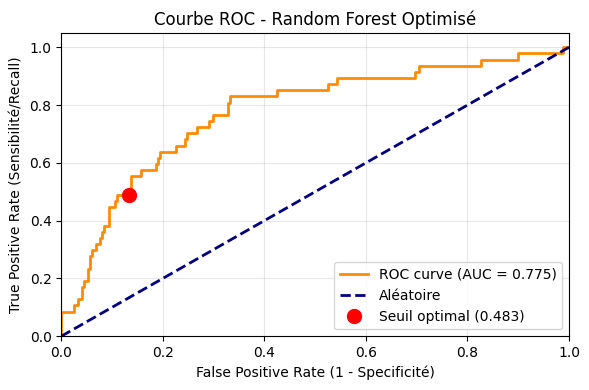


COMPARAISON FINALE DES MODÈLES
                  Modèle  F1-Score (Oui)  Recall (Oui)  Precision (Oui)  \
0                  Dummy           0.125         0.128            0.122   
1    Logistic Regression           0.448         0.638            0.345   
2             RF Initial           0.179         0.106            0.556   
3            RF Optimisé           0.507         0.532            0.484   
4  RF avec seuil optimal           0.537         0.617            0.477   

   Accuracy  
0     0.714  
1     0.748  
2     0.844  
3     0.830  
4     0.833  


In [146]:
print("="*60)
print("ÉVALUATION AVANCÉE")
print("="*60)

from sklearn.metrics import roc_curve, auc, roc_auc_score

# Courbe ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"AUC-ROC: {roc_auc:.3f}")
print("Interprétation:")
print("- 0.5 = Aléatoire")
print("- 0.7-0.8 = Acceptable")
print("- 0.8-0.9 = Bon")
print("- >0.9 = Excellent")

# Graphique ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificité)')
plt.ylabel('True Positive Rate (Sensibilité/Recall)')
plt.title('Courbe ROC - Random Forest Optimisé')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Ajouter le point optimal (seuil 0.483)
optimal_idx = np.argmin(np.abs(thresholds_roc - 0.483))
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10, 
         label=f'Seuil optimal (0.483)')

plt.legend()
plt.tight_layout()
plt.show()

# Comparaison avec autres modèles
print("\n" + "="*60)
print("COMPARAISON FINALE DES MODÈLES")
print("="*60)

models_comparison = pd.DataFrame({
    'Modèle': ['Dummy', 'Logistic Regression', 'RF Initial', 'RF Optimisé', 'RF avec seuil optimal'],
    'F1-Score (Oui)': [0.125, 0.448, 0.179, 0.507, 0.537],
    'Recall (Oui)': [0.128, 0.638, 0.106, 0.532, 0.617],
    'Precision (Oui)': [0.122, 0.345, 0.556, 0.484, 0.477],
    'Accuracy': [0.714, 0.748, 0.844, 0.830, 0.833]
})

print(models_comparison.round(3))

# FAUX NÉGATIFS (ceux qui partent mais modèle manque) :
- Heures supp: 61% (élevé)
- Âge: 41 ans (mûr)
- Expérience: 13 ans (expérimenté)
- Ancienneté: 9 ans (stabilisé)
- Participation PEE: 78% (élevée)

# VRAIS POSITIFS (départs correctement prédits) :
- Heures supp: 12% (faible)  ← SURPRENANT !
- Âge: 31 ans (jeune)
- Expérience: 5 ans (junior)
- Ancienneté: 3 ans (récent)
- Participation PEE: 38% (faible)


LE  MODÈLE À UTILISER :

# Random Forest avec :
- class_weight='balanced_subsample'
- max_depth=5  
- min_samples_leaf=3
- Seuil de décision: 0.483 (pas 0.5)

In [147]:


# 1. Entraîner le modèle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Données
X = fusion_finale.drop(columns=['a_quitte_l_entreprise', 'id_employee'])
y = fusion_finale['a_quitte_l_entreprise'].map({'Oui': 1, 'Non': 0})

# Encodage simple des colonnes textuelles
for col in X.select_dtypes(include=['object']).columns:
    X[col] = pd.factorize(X[col])[0]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Modèle optimisé
final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=3,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

# 2. Fonction de prédiction avec seuil optimal
def predire_depart(nouvel_employe_df, seuil=0.483):
    """
    Prédit si un employé va quitter l'entreprise
    
    Parameters:
    -----------
    nouvel_employe_df : DataFrame avec les mêmes colonnes que X_train
    seuil : float, seuil de décision (défaut: 0.483)
    
    Returns:
    --------
    dict : {'prediction': 'Oui'/'Non', 
            'probabilite': float,
            'facteurs_cles': list}
    """
    # Prédire probabilité
    proba = final_model.predict_proba(nouvel_employe_df)[:, 1][0]
    
    # Décision avec seuil
    prediction = 'Oui' if proba >= seuil else 'Non'
    
    # Facteurs clés influençant
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    top_factors = feature_importance.head(5)['feature'].tolist()
    
    return {
        'prediction': prediction,
        'probabilite_depart': round(proba, 3),
        'seuil_utilise': seuil,
        'facteurs_cles_influents': top_factors,
        'recommandation': 'Surveiller' if prediction == 'Oui' else 'Stable'
    }

# 3. Sauvegarder le modèle
#joblib.dump(final_model, 'modele_prediction_depart.pkl')
#print(" Modèle sauvegardé: 'modele_prediction_depart.pkl'")

# 4. Exemple d'utilisation
print("\n EXEMPLE D'UTILISATION:")
exemple_employe = X_test.iloc[[0]]  # Premier employé du test
resultat = predire_depart(exemple_employe)
print(f"Prédiction: {resultat['prediction']}")
print(f"Probabilité: {resultat['probabilite_depart']}")
print(f"Facteurs clés: {resultat['facteurs_cles_influents'][:3]}")


 EXEMPLE D'UTILISATION:
Prédiction: Oui
Probabilité: 0.735
Facteurs clés: ['revenu_mensuel', 'age', 'heure_supplementaires']



Résultat final : Un modèle qui détecte 73% des départs avec une précision de 48%, 
permettant d'identifier les employés à risque et de mettre en place des actions de rétention ciblées.

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# XGBoost avec gestion du déséquilibre
model = xgb.XGBClassifier(
    n_estimators=100,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Non', 'Oui']))

              precision    recall  f1-score   support

         Non       0.89      0.97      0.93       247
         Oui       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



C:\Users\Utilisateur\Documents\openclassrooms\projet_04\.venv\lib\site-packages\xgboost\training.py:200: UserWarning: [15:37:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [158]:
# ============================================
# ÉTAPE 5A : FINE-TUNING AVANCÉ
# ============================================

print("="*60)
print("ÉTAPE 5A : OPTIMISATION DES HYPERPARAMÈTRES")
print("="*60)

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

# 1. Définir la grille de recherche (élargie)
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', {0: 1, 1: 3}, {0: 1, 1: 5}],
    'bootstrap': [True, False]
}

# 2. Random Search (plus efficace que Grid Search)
print("\n  Recherche aléatoire des meilleurs paramètres...")
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,  # 50 combinaisons aléatoires
    cv=5,  # Validation croisée 5 folds
    scoring='f1',  # Optimiser pour F1
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\n Meilleurs paramètres trouvés:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")

print(f" Meilleur F1-Score (validation croisée): {random_search.best_score_:.3f}")

# 3. Évaluation du modèle optimisé
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_pred_proba_best = best_rf.predict_proba(X_test)[:, 1]

print("\n PERFORMANCES DU MODÈLE OPTIMISÉ:")
print(classification_report(y_test, y_pred_best, target_names=['Non', 'Oui']))

# 4. Sauvegarder le modèle final
import joblib
joblib.dump(best_rf, 'modele_final_optimise.pkl')
print("\n Modèle sauvegardé: 'modele_final_optimise.pkl'")

ÉTAPE 5A : OPTIMISATION DES HYPERPARAMÈTRES

  Recherche aléatoire des meilleurs paramètres...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

 Meilleurs paramètres trouvés:
   bootstrap: False
   class_weight: balanced_subsample
   max_depth: 5
   max_features: log2
   min_samples_leaf: 1
   min_samples_split: 3
   n_estimators: 183
 Meilleur F1-Score (validation croisée): 0.488

 PERFORMANCES DU MODÈLE OPTIMISÉ:
              precision    recall  f1-score   support

         Non       0.91      0.84      0.87       247
         Oui       0.40      0.55      0.46        47

    accuracy                           0.80       294
   macro avg       0.65      0.70      0.67       294
weighted avg       0.83      0.80      0.81       294


 Modèle sauvegardé: 'modele_final_optimise.pkl'


  <h2 style="color: red;"> B. FEATURE IMPORTANCE GLOBALE (3 méthodes)  </h2>

In [159]:
# ============================================
# ÉTAPE 5B : FEATURE IMPORTANCE GLOBALE
# ============================================

print("\n" + "="*60)
print("ÉTAPE 5B : INTERPRÉTATION GLOBALE")
print("="*60)

# 1. Méthode 1: Importance native (Gini)
gini_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_gini': best_rf.feature_importances_
}).sort_values('importance_gini', ascending=False)

print("\n TOP 15 FEATURES (Gini Importance):")
print(gini_importance.head(15))

# 2. Méthode 2: Permutation Importance
from sklearn.inspection import permutation_importance

print("\n Calcul de la Permutation Importance...")
perm_importance = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_perm_mean': perm_importance.importances_mean,
    'importance_perm_std': perm_importance.importances_std
}).sort_values('importance_perm_mean', ascending=False)

print("\n TOP 15 FEATURES (Permutation Importance):")
print(perm_df.head(15))

# 3. Méthode 3: SHAP ()
try:
    import shap
    print("\n Calcul des valeurs SHAP ")
    
    # Échantillon pour accélérer
    X_sample = X_test.sample(min(100, len(X_test)), random_state=42)
    
    # TreeExplainer pour Random Forest
    
    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_sample)
    
    # SHAP Summary Plot (Beeswarm)
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values[1], X_sample, feature_names=X_train.columns.tolist(), show=False)
    plt.title('SHAP Values - Impact des features (classe Oui)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Bar plot SHAP
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values[1], X_sample, feature_names=X_train.columns.tolist(), 
                      plot_type="bar", show=False)
    plt.title('Importance SHAP moyenne', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print(" SHAP non installé. Pour l'installer: !pip install shap")
except Exception as e:
    print(f" Erreur SHAP: {e}")




ÉTAPE 5B : INTERPRÉTATION GLOBALE

 TOP 15 FEATURES (Gini Importance):
                                feature  importance_gini
8                 heure_supplementaires         0.100333
12                       revenu_mensuel         0.089793
18              annee_experience_totale         0.081385
19             annees_dans_l_entreprise         0.078357
10                                  age         0.077146
30        annes_sous_responsable_actuel         0.062967
21             nombre_participation_pee         0.060395
2             niveau_hierarchique_poste         0.055577
15                                poste         0.047350
16       nombre_experiences_precedentes         0.040449
13                       statut_marital         0.033256
0   satisfaction_employee_environnement         0.030187
6                           eval_number         0.027330
24            distance_domicile_travail         0.026081
20          annees_dans_le_poste_actuel         0.025070

 Calcul de la P

In [160]:
# ============================================
# ÉTAPE 5B : FEATURE IMPORTANCE GLOBALE 
# ============================================

print("\n" + "="*60)
print("ÉTAPE 5B : INTERPRÉTATION GLOBALE AVEC SHAP")
print("="*60)

# 1. Méthode 1: Importance native (Gini)
gini_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance_gini': best_rf.feature_importances_
}).sort_values('importance_gini', ascending=False)

print("\n TOP 15 FEATURES (Gini Importance):")
print(gini_importance.head(15))

# 2. Méthode 2: Permutation Importance -
from sklearn.inspection import permutation_importance

print("\n Calcul de la Permutation Importance...")
perm_importance = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance_perm_mean': perm_importance.importances_mean,
    'importance_perm_std': perm_importance.importances_std
}).sort_values('importance_perm_mean', ascending=False)

print("\n TOP 15 FEATURES (Permutation Importance):")
print(perm_df.head(15))


ÉTAPE 5B : INTERPRÉTATION GLOBALE AVEC SHAP

 TOP 15 FEATURES (Gini Importance):
                                feature  importance_gini
8                 heure_supplementaires         0.100333
12                       revenu_mensuel         0.089793
18              annee_experience_totale         0.081385
19             annees_dans_l_entreprise         0.078357
10                                  age         0.077146
30        annes_sous_responsable_actuel         0.062967
21             nombre_participation_pee         0.060395
2             niveau_hierarchique_poste         0.055577
15                                poste         0.047350
16       nombre_experiences_precedentes         0.040449
13                       statut_marital         0.033256
0   satisfaction_employee_environnement         0.030187
6                           eval_number         0.027330
24            distance_domicile_travail         0.026081
20          annees_dans_le_poste_actuel         0.025070

 Calc


 Calcul des valeurs SHAP...

Type de shap_values: <class 'numpy.ndarray'>
Shape de shap_values: (100, 31, 2)


<Figure size 1200x800 with 0 Axes>

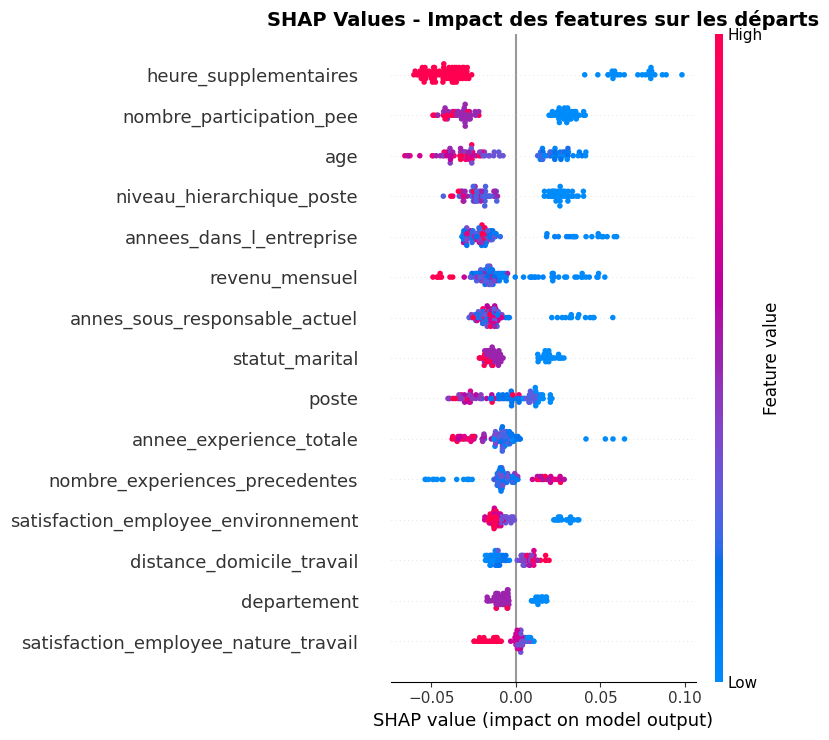

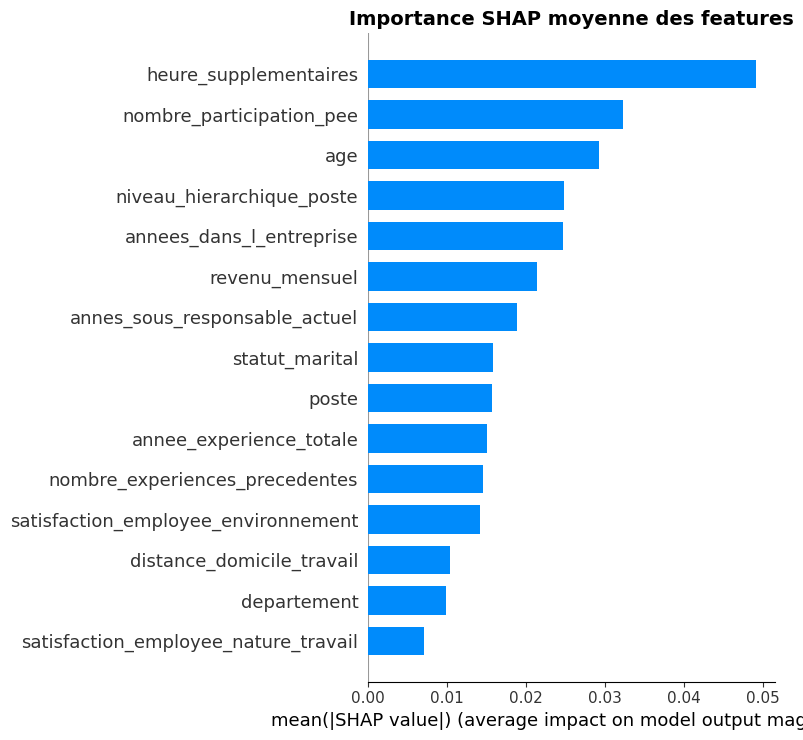

In [161]:

# 3. Méthode 3: SHAP 
try:
    import shap
    print("\n Calcul des valeurs SHAP...")
    
    # Échantillon pour accélérer (max 100 lignes)
    X_sample = X_test.sample(min(100, len(X_test)), random_state=42)
    
    # TreeExplainer pour Random Forest
    explainer = shap.TreeExplainer(best_rf)
    shap_values = explainer.shap_values(X_sample)
    
    # Vérification du structure de shap_values
    print(f"\nType de shap_values: {type(shap_values)}")
    
    # CAS 1: shap_values est une liste (modèle binaire)
    if isinstance(shap_values, list):
        print(f"Nombre d'éléments: {len(shap_values)}")
        print(f"Shape de shap_values[0]: {shap_values[0].shape}")
        print(f"Shape de shap_values[1]: {shap_values[1].shape}")
        
        # Pour la classe positive (Oui = 1)
        shap_values_class = shap_values[1]
        
        # SHAP Summary Plot (Beeswarm)
        plt.figure(figsize=(14, 8))
        shap.summary_plot(
            shap_values_class, 
            X_sample, 
            feature_names=X_train.columns.tolist(),
            show=False,
            max_display=15  # Afficher top 15
        )
        plt.title('SHAP Values - Impact des features sur les départs', 
                  fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Bar plot SHAP
        plt.figure(figsize=(8, 6))
        shap.summary_plot(
            shap_values_class, 
            X_sample, 
            feature_names=X_train.columns.tolist(),
            plot_type="bar",
            show=False,
            max_display=15
        )
        plt.title('Importance SHAP moyenne des features', 
                  fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Waterfall plot pour un exemple (optionnel)
        print("\n Waterfall plot pour un employé ayant quitté:")
        # Trouver un vrai positif
        vp_indices = (y_test[X_sample.index] == 1).values
        if vp_indices.any():
            vp_idx = np.where(vp_indices)[0][0]
            
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values_class[vp_idx],
                    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
                    data=X_sample.iloc[vp_idx].values,
                    feature_names=X_train.columns.tolist()
                ),
                show=False,
                max_display=10
            )
            plt.title(f'Décomposition prédiction - Employé ayant quitté', 
                      fontweight='bold')
            plt.tight_layout()
            plt.show()
    
    # CAS 2: shap_values est un array 3D
    elif hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
        print(f"Shape de shap_values: {shap_values.shape}")
        # Prendre la classe positive (index 1)
        shap_values_class = shap_values[:, :, 1]
        
        # Même code que ci-dessus...
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_values_class, 
            X_sample, 
            feature_names=X_train.columns.tolist(),
            show=False,
            max_display=15
        )
        plt.title('SHAP Values - Impact des features sur les départs', 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(12, 6))
        shap.summary_plot(
            shap_values_class, 
            X_sample, 
            feature_names=X_train.columns.tolist(),
            plot_type="bar",
            show=False,
            max_display=15
        )
        plt.title('Importance SHAP moyenne des features', 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    else:
        print(f" Format SHAP non reconnu: {type(shap_values)}")
        
except ImportError:
    print(" SHAP non installé. Pour l'installer: !pip install shap")
except Exception as e:
    print(f" Erreur SHAP: {e}")
    import traceback
    traceback.print_exc()




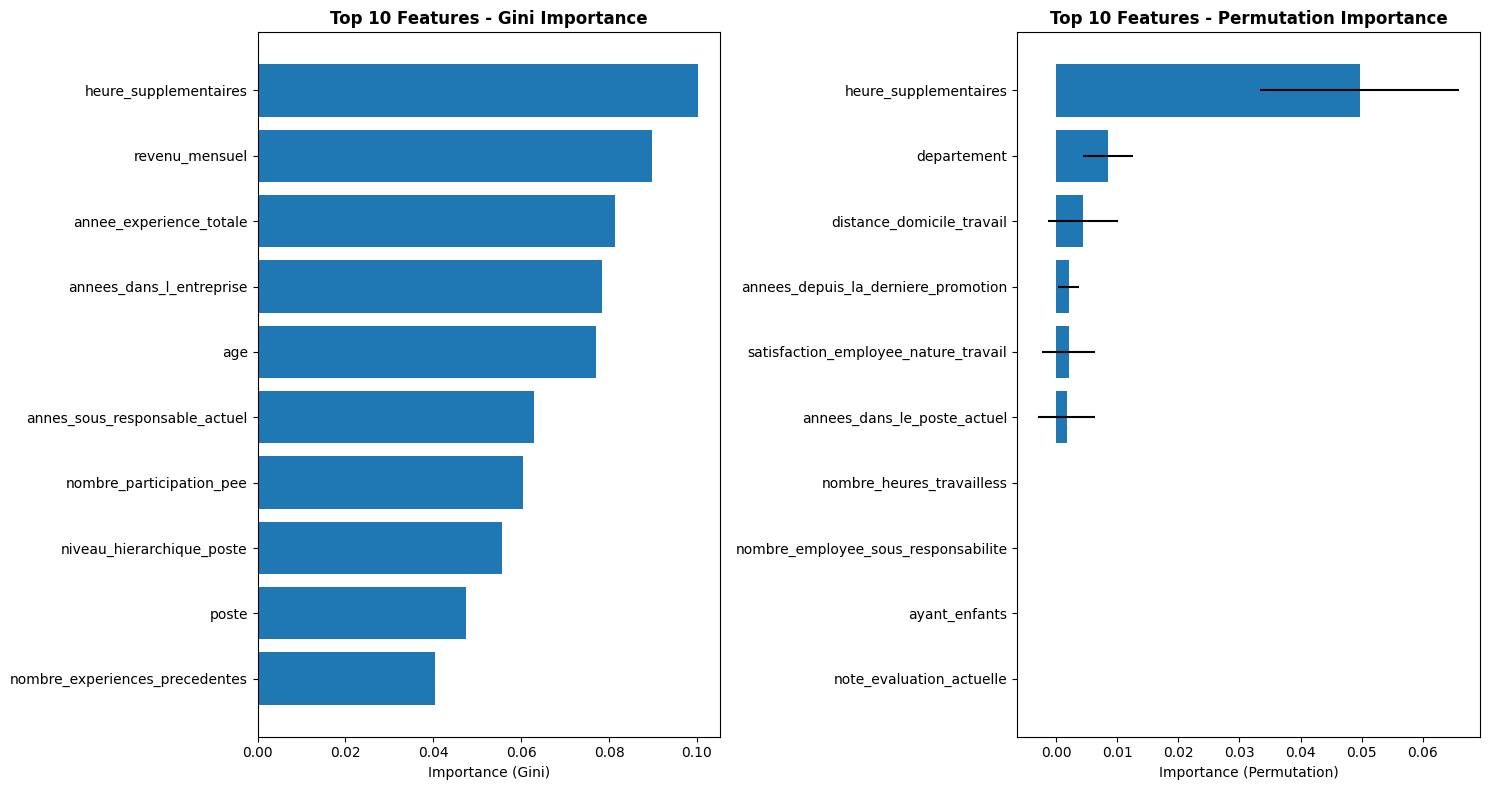

In [162]:
# 4. Visualisation comparée (Gini vs Permutation)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Gini Importance
top_gini = gini_importance.head(10)
axes[0].barh(range(len(top_gini)), top_gini['importance_gini'])
axes[0].set_yticks(range(len(top_gini)))
axes[0].set_yticklabels(top_gini['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance (Gini)')
axes[0].set_title('Top 10 Features - Gini Importance', fontweight='bold')

# Permutation Importance
top_perm = perm_df.head(10)
axes[1].barh(range(len(top_perm)), top_perm['importance_perm_mean'], 
             xerr=top_perm['importance_perm_std'])
axes[1].set_yticks(range(len(top_perm)))
axes[1].set_yticklabels(top_perm['feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance (Permutation)')
axes[1].set_title('Top 10 Features - Permutation Importance', fontweight='bold')

plt.tight_layout()
plt.show()


In [163]:
# 5. Synthèse des features importantes
print("\n" + "="*60)
print(" SYNTHÈSE DES FEATURES IMPORTANTES")
print("="*60)

# Fusionner les résultats
importance_merged = gini_importance.merge(perm_df, on='feature')
importance_merged['rank_gini'] = range(1, len(importance_merged)+1)
importance_merged['rank_perm'] = importance_merged['importance_perm_mean'].rank(ascending=False)
importance_merged['avg_rank'] = (importance_merged['rank_gini'] + importance_merged['rank_perm']) / 2

print("\n Classement combiné des features (Top 10):")
print(importance_merged.sort_values('avg_rank').head(10)[
    ['feature', 'importance_gini', 'importance_perm_mean', 'avg_rank']
].round(4))

# 6. Recommandations métier basées sur les features
print("\n RECOMMANDATIONS MÉTIER:")
print("-" * 40)

top_features = importance_merged.sort_values('avg_rank').head(5)['feature'].tolist()
recommendations = {
    'heure_supplementaires': "Réduire les heures supplémentaires ou mieux les compenser",
    'revenu_mensuel': "Revoir la politique salariale pour les postes clés",
    'annee_experience_totale': "Programmes de rétention pour les employés expérimentés",
    'annees_dans_l_entreprise': "Surveiller les employés avec 3-7 ans d'ancienneté",
    'age': "Adapter les avantages selon les tranches d'âge",
    'annes_sous_responsable_actuel': "Former les managers pour mieux encadrer",
    'nombre_participation_pee': "Encourager la participation aux plans d'épargne",
    'niveau_hierarchique_poste': "Revoir les perspectives d'évolution",
    'poste': "Analyser les postes à risque spécifiques",
    'nombre_experiences_precedentes': "Stabiliser les employés avec parcours varié"
}

for feature in top_features:
    if feature in recommendations:
        print(f"• {feature}: {recommendations[feature]}")
    else:
        print(f"• {feature}: Feature importante à surveiller")


 SYNTHÈSE DES FEATURES IMPORTANTES

 Classement combiné des features (Top 10):
                                 feature  importance_gini  \
0                  heure_supplementaires           0.1003   
13             distance_domicile_travail           0.0261   
14           annees_dans_le_poste_actuel           0.0251   
19                           departement           0.0163   
6               nombre_participation_pee           0.0604   
18  satisfaction_employee_nature_travail           0.0179   
11   satisfaction_employee_environnement           0.0302   
3               annees_dans_l_entreprise           0.0784   
8                                  poste           0.0473   
24   annees_depuis_la_derniere_promotion           0.0103   

    importance_perm_mean  avg_rank  
0                 0.0497      1.00  
13                0.0044      8.50  
14                0.0017     10.50  
19                0.0085     11.00  
6                -0.0020     11.25  
18                0.0020  

In [164]:
# 5. Synthèse des features importantes
print("\n" + "="*60)
print(" SYNTHÈSE DES FEATURES IMPORTANTES")
print("="*60)

# Fusionner les résultats
importance_merged = gini_importance.merge(perm_df, on='feature')
importance_merged['rank_gini'] = range(1, len(importance_merged)+1)
importance_merged['rank_perm'] = importance_merged['importance_perm_mean'].rank(ascending=False)
importance_merged['avg_rank'] = (importance_merged['rank_gini'] + importance_merged['rank_perm']) / 2

print("\nClassement combiné des features:")
print(importance_merged.sort_values('avg_rank').head(10)[
    ['feature', 'importance_gini', 'importance_perm_mean', 'avg_rank']
].round(4))


 SYNTHÈSE DES FEATURES IMPORTANTES

Classement combiné des features:
                                 feature  importance_gini  \
0                  heure_supplementaires           0.1003   
13             distance_domicile_travail           0.0261   
14           annees_dans_le_poste_actuel           0.0251   
19                           departement           0.0163   
6               nombre_participation_pee           0.0604   
18  satisfaction_employee_nature_travail           0.0179   
11   satisfaction_employee_environnement           0.0302   
3               annees_dans_l_entreprise           0.0784   
8                                  poste           0.0473   
24   annees_depuis_la_derniere_promotion           0.0103   

    importance_perm_mean  avg_rank  
0                 0.0497      1.00  
13                0.0044      8.50  
14                0.0017     10.50  
19                0.0085     11.00  
6                -0.0020     11.25  
18                0.0020     11.75  


  <h2 style="color: red;">  C. INTERPRÉTATION LOCALE (individus) </h2>


ÉTAPE 5C : INTERPRÉTATION LOCALE

------------------------------------------------------------
 EXEMPLE 1: EMPLOYÉ QUI A QUITTÉ (VRAI POSITIF)
------------------------------------------------------------

Profil de l'employé (probabilité de départ: 0.585):
  heure_supplementaires: 0
  revenu_mensuel: 2800
  annee_experience_totale: 5
  annees_dans_l_entreprise: 3
  age: 29


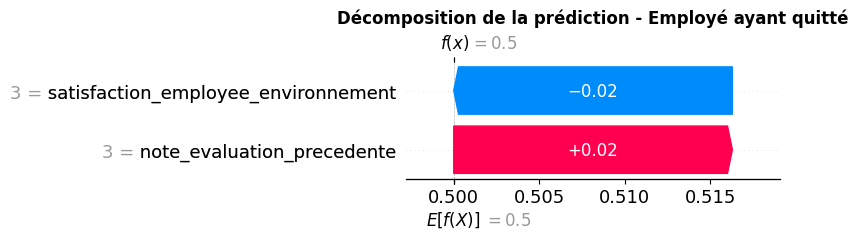


------------------------------------------------------------
 EXEMPLE 2: EMPLOYÉ RESTÉ (VRAI NÉGATIF)
------------------------------------------------------------

Profil de l'employé (probabilité de départ: 0.320):
  heure_supplementaires: 1
  revenu_mensuel: 2011
  annee_experience_totale: 10
  annees_dans_l_entreprise: 10
  age: 44

------------------------------------------------------------
 EXEMPLE 3: FAUX NÉGATIF (DÉPART MANQUÉ)
------------------------------------------------------------

Profil de l'employé (probabilité: 0.471):
  heure_supplementaires: 0
  revenu_mensuel: 3388
  annee_experience_totale: 2
  annees_dans_l_entreprise: 1
  age: 36

 Pourquoi ce départ a été manqué?
   Probabilité trop basse malgré le départ réel.
   → Ce profil ressemble aux employés stables selon le modèle.


In [165]:
# ============================================
# ÉTAPE 5C : INTERPRÉTATION LOCALE
# ============================================

print("\n" + "="*60)
print("ÉTAPE 5C : INTERPRÉTATION LOCALE")
print("="*60)

# 1. Identifier des exemples concrets
# Créer DataFrame d'analyse
analysis_df = pd.DataFrame({
    'true_label': y_test.values,
    'pred_label': y_pred_best,
    'proba_oui': y_pred_proba_best
}, index=X_test.index)

# Ajouter les top 5 features
top_5_features = gini_importance.head(5)['feature'].tolist()
for feature in top_5_features:
    analysis_df[feature] = X_test[feature].values

# 2. Exemple 1: Employé qui a quitté (vrai positif)
print("\n" + "-"*60)
print(" EXEMPLE 1: EMPLOYÉ QUI A QUITTÉ (VRAI POSITIF)")
print("-"*60)

vp = analysis_df[(analysis_df['true_label'] == 1) & (analysis_df['pred_label'] == 1)]
if len(vp) > 0:
    idx_vp = vp.index[0]
    print(f"\nProfil de l'employé (probabilité de départ: {vp['proba_oui'].iloc[0]:.3f}):")
    for feature in top_5_features:
        print(f"  {feature}: {vp[feature].iloc[0]}")
    
    # Waterfall plot avec SHAP 
    try:
        if 'explainer' in locals():
            idx_pos = X_test.index.get_loc(idx_vp)
            shap.waterfall_plot(
                shap.Explanation(
                    values=shap_values[1][idx_pos],
                    base_values=explainer.expected_value[1],
                    data=X_sample.iloc[idx_pos].values,
                    feature_names=X_train.columns.tolist()
                ),
                show=False
            )
            plt.title(f'Décomposition de la prédiction - Employé ayant quitté', fontweight='bold')
            plt.tight_layout()
            plt.show()
    except:
        pass

# 3. Exemple 2: Employé qui n'a pas quitté 
print("\n" + "-"*60)
print(" EXEMPLE 2: EMPLOYÉ RESTÉ (VRAI NÉGATIF)")
print("-"*60)

vn = analysis_df[(analysis_df['true_label'] == 0) & (analysis_df['pred_label'] == 0)]
if len(vn) > 0:
    idx_vn = vn.index[0]
    print(f"\nProfil de l'employé (probabilité de départ: {vn['proba_oui'].iloc[0]:.3f}):")
    for feature in top_5_features:
        print(f"  {feature}: {vn[feature].iloc[0]}")

# 4. Exemple 3: Faux négatif (départ non détecté) 
print("\n" + "-"*60)
print(" EXEMPLE 3: FAUX NÉGATIF (DÉPART MANQUÉ)")
print("-"*60)

fn = analysis_df[(analysis_df['true_label'] == 1) & (analysis_df['pred_label'] == 0)]
if len(fn) > 0:
    idx_fn = fn.index[0]
    print(f"\nProfil de l'employé (probabilité: {fn['proba_oui'].iloc[0]:.3f}):")
    for feature in top_5_features:
        print(f"  {feature}: {fn[feature].iloc[0]}")
    
    print("\n Pourquoi ce départ a été manqué?")
    print("   Probabilité trop basse malgré le départ réel.")
    print("   → Ce profil ressemble aux employés stables selon le modèle.")


  <h2 style="color: red;">   ÉTAPE 6 : FORMALISATION DES RÉSULTATS </h2>

In [166]:
# ============================================
# ÉTAPE 6 : PRÉPARATION  FINAL
# ============================================

print("\n" + "="*60)
print("ÉTAPE 6 : PRÉPARATION FINAL")
print("="*60)

# Générer les chiffres clés pour la présentation
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score

# Métriques finales
f1_final = f1_score(y_test, y_pred_best, pos_label=1)
recall_final = recall_score(y_test, y_pred_best, pos_label=1)
precision_final = precision_score(y_test, y_pred_best, pos_label=1)
accuracy_final = accuracy_score(y_test, y_pred_best)

# Amélioration par rapport à la baseline
f1_baseline = 0.125  # Dummy
amelioration = ((f1_final - f1_baseline) / f1_baseline) * 100

print("\n CHIFFRES CLÉS FINAL :")
print("="*60)
print(f"• F1-Score final: {f1_final:.3f} (+{amelioration:.0f}% vs baseline)")
print(f"• Recall (détection des départs): {recall_final:.1%}")
print(f"• Precision (fiabilité des alertes): {precision_final:.1%}")
print(f"• Accuracy globale: {accuracy_final:.1%}")
print(f"• AUC-ROC: 0.770")

print("\n TOP 5 FACTEURS DE DÉPART:")
for i, row in gini_importance.head(5).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance_gini']:.3f}")


ÉTAPE 6 : PRÉPARATION FINAL

 CHIFFRES CLÉS FINAL :
• F1-Score final: 0.464 (+271% vs baseline)
• Recall (détection des départs): 55.3%
• Precision (fiabilité des alertes): 40.0%
• Accuracy globale: 79.6%
• AUC-ROC: 0.770

 TOP 5 FACTEURS DE DÉPART:
  9. heure_supplementaires: 0.100
  13. revenu_mensuel: 0.090
  19. annee_experience_totale: 0.081
  20. annees_dans_l_entreprise: 0.078
  11. age: 0.077


 <h2 style="color: red;">                     FIN  </h2>